# 05b_Analyze — Black-Litterman 실험 결과 분석

본 노트북은 `final/results/*.pkl` 백테스트 결과를 분석하는 단일 진입점.

## 구조 (실행 순서대로)

```
[Setup]   데이터 로드             — pkl + rf + SPY
[K_CUT]   2023-12-31 cutoff       ★ MANDATORY ★ — 모든 후속 분석을 컷 적용 상태로 통일

[I] 거래비용 분석                  — 슬롯별 turnover & TC
    ├─ I1  슬롯별 Turnover & TC 집계
    └─ I2  Trailing vs LSTM Turnover 직접 비교

[J] Master Table 통합             — 슬롯 효과 + 매트릭스 + Top-N + 위기 + IR
    ├─ J1  Master Table 빌드
    └─ J2  슬롯별 marginal effect (sharpe + sortino)

[K] 레짐 안정성                    — 3-레짐 sortino_ir / sharpe_ir Top 20
    ├─ K1     레짐 테이블 + 4-view 정렬 + 핵심 비교군 4종
    ├─ K2     Sortino IR Top 20 통합 대시보드
    ├─ K2-T   Sortino IR Top 20 — 전체기간 메트릭 표
    ├─ K2-M   전체기간 Sortino Top 20 × 3 metric 히트맵
    ├─ K2-MT  전체기간 Sortino Top 20 — 전체기간 메트릭 표
    ├─ K2-X50 Sortino IR ∩ 전체기간 Sortino Top 50 — 확장 교집합
    └─ K7     baseline Q 민감도 — q_value ∈ {0.003, 0.0055, 0.0064, 0.0070}

[L] 전체 슬롯 메트릭 CSV          — slot raw export
    ├─ L1  전체 슬롯 × 전체기간 메트릭 CSV
    └─ L2  전체 슬롯 × 레짐별 메트릭 CSV

[M] Winner Q 민감도 (winner=mat_eq_eq_lam_pap)
    ├─ M1  메트릭 테이블 (q sweep)
    ├─ M2  라인플롯 (전체기간 + 레짐별 6 subplot)
    └─ M3  통계 검정 — Jobson-Korkie + Block Bootstrap CI

[N] Winner PCT_GROUP 민감도
    ├─ N1  메트릭 테이블 (pct sweep)
    ├─ N2  라인플롯 (전체기간 + 레짐별 6 subplot)
    ├─ N3  통계 검정 — Jobson-Korkie + Block Bootstrap CI
    └─ N4  포트폴리오 구성 변화 (eff_n / turnover)
```

**필터 정책** — `mt`/`rt`(J/K/L 등 일반 슬롯 분석)는 sensitivity sweep 변형 자동 제외:
- `_q55/_q64/_q70` (K7 baseline q sweep)
- `winner_q*`, `winner_pct*` (M/N winner sweep)

→ M/N sensitivity 분석에서만 `mt_full`/`rt_full` 사용해 sweep 슬롯 접근.

> ⚠️ **데이터 소스**: `results/` (현행)만 사용. `results_backup/`은 vol_pred 단위 혼합 버그 (2026-05-07 이전, LSTM `np.exp(y_pred)`에 `× √252` 누락)로 생성된 LSTM 슬롯 결과로 **분석에 절대 사용 금지**. 자세한 경위는 [`BL_EXPERIMENT_GUIDE.md`](BL_EXPERIMENT_GUIDE.md) §4.1 / §9.

> ⚠️ **Look-ahead bias**: K_CUT을 가장 먼저 실행해 2010-01~2023-12 (168개월)로 통일. 2024-2025는 Phase 2 holdout 평가용으로 보존 — 선정 단계에서 절대 참조 금지.

> 📈 **슬롯 차원 효과 시각화**: [`99_slot_effects.ipynb`](99_slot_effects.ipynb) — 본 노트북의 L1 CSV를 입력으로 받아 dim 효과 라인플롯 생성. 자체적으로 pivot CSV 5개 생성.

셀별 해설: 노트북 안 markdown 셀 참고.

> ⭐ **ACTIVE_TC**: 분석에 적용할 거래비용 (편측). pkl 손 안 대고 `ret = gross_ret - turnover × ACTIVE_TC` 로 on-the-fly 재계산. 시나리오 비교 시 이 값만 바꾸면 됨.


In [ ]:
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import warnings
import platform
from pathlib import Path

warnings.filterwarnings('ignore')

if platform.system() == 'Darwin':
    plt.rcParams['font.family']     = 'sans-serif'
    plt.rcParams['font.sans-serif'] = ['AppleGothic', 'Apple SD Gothic Neo', 'NanumGothic', 'Arial Unicode MS', 'DejaVu Sans']
elif platform.system() == 'Windows':
    plt.rcParams['font.family']     = 'sans-serif'
    plt.rcParams['font.sans-serif'] = ['Malgun Gothic', 'Arial Unicode MS', 'DejaVu Sans']
else:
    plt.rcParams['font.family']     = 'sans-serif'
    plt.rcParams['font.sans-serif'] = ['NanumGothic', 'Noto Sans CJK KR', 'DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False

RESULTS_DIR = Path.cwd() / 'results'
OUT_DIR     = Path.cwd() / 'outputs' / '05b_Analyze'
OUT_DIR.mkdir(parents=True, exist_ok=True)

# ── 결과 로드 ──────────────────────────────────────────────────
loaded = {}
for pkl in sorted(RESULTS_DIR.glob('*.pkl')):
    with open(pkl, 'rb') as f:
        loaded[pkl.stem] = pickle.load(f)

# ── rf 로드 ────────────────────────────────────────────────────
panel_rf = pd.read_csv(Path.cwd() / 'data' / 'monthly_panel.csv',
                       usecols=['date','ticker','rf_1m'], parse_dates=['date'])
rf = panel_rf.groupby('date')['rf_1m'].first()

spy_ret = loaded['mat_mcap_mcap_fix_he']['spy_ret'].dropna()

# ── 성과 계산 함수 ──────────────────────────────────────────────
def calc(name):
    r    = loaded[name]['ret'].dropna()
    rf_a = rf.reindex(r.index).fillna(0)
    exc  = r - rf_a
    ann  = exc.mean() * 12
    vol  = r.std() * np.sqrt(12)
    sh   = ann / vol if vol > 0 else np.nan
    cum  = (1 + r).cumprod()
    mdd  = ((cum / cum.cummax()) - 1).min()
    dsd  = r[r < 0].std() * np.sqrt(12)
    sor  = ann / dsd if dsd > 0 else np.nan
    tot  = cum.iloc[-1] - 1
    cagr = r.mean() * 12
    return dict(sharpe=sh, cagr=cagr, vol=vol, mdd=mdd,
                sortino=sor, total=tot, ret=r, cum=cum)

# SPY 성과
def calc_spy():
    r    = spy_ret
    rf_a = rf.reindex(r.index).fillna(0)
    exc  = r - rf_a
    ann  = exc.mean() * 12
    vol  = r.std() * np.sqrt(12)
    sh   = ann / vol
    cum  = (1 + r).cumprod()
    mdd  = ((cum / cum.cummax()) - 1).min()
    return dict(sharpe=sh, cagr=r.mean()*12, vol=vol, mdd=mdd, total=cum.iloc[-1]-1, cum=cum)

print(f'로드 완료: {len(loaded)}개 실험')
print(f'기간: {loaded["mat_mcap_mcap_fix_he"]["ret"].index[0].date()} ~ {loaded["mat_mcap_mcap_fix_he"]["ret"].index[-1].date()}')


## K_CUT. 2023-12-31 cutoff 적용 (모든 후속 분석에 mandatory)

기존 백테스트 결과(`results/*.pkl`)는 2010-01 ~ 2024-12 (180개월). **본 셀을 데이터 로드 직후 가장 먼저 실행**해서 모든 ret/spy_ret/comp을 **2023-12-31까지로 truncate** 한 임시 pkl을 `outputs/05b_analyze/_cut_pkl/`에 저장하고, `RESULTS_DIR`를 그쪽으로 재지정.

**왜 mandatory인가** — Look-ahead bias 방지:
- 2024-2025를 Phase 2 holdout으로 사용할 예정 → **선정 단계(2010-2023)에 holdout 데이터 leak 금지**
- 셀 3 turnover, J1/J2 슬롯 효과, K1~K7 레짐 분석, L1/L2 CSV 등 **모든 후속 셀이 자동으로 컷 적용된 mt/rt/loaded 사용**
- 예외 1개: `_ORIG_RESULTS_DIR`는 보존 — Phase 2 단계에서 winner 슬롯의 2024-2025 데이터 로드용

**효과 범위** (이 셀 실행 후 노트북 전체):
- `loaded[name]['ret']/['spy_ret']/['comp']` 모두 ≤ 2023-12-31
- `RESULTS_DIR = outputs/05b_analyze/_cut_pkl/`
- `mt`, `rt`, `rt_sm`이 cut 기준으로 사전 빌드됨 (J1/K1에서 다시 빌드해도 동일)
- 기준 슬롯 `baseline_ret` (= `mat_mcap_mcap_fix_he`) 도 cut

> ⚠️ 컷 해제하려면 노트북 처음부터 다시 실행. 본 셀을 SKIP하면 leakage 위험 ⚠️


In [ ]:
# ── K_CUT. 2023-12-31 cutoff (MANDATORY, 데이터 로드 직후 실행) ─────────
# 모든 ret/comp을 CUTOFF까지 truncate한 임시 pkl 디렉토리 생성 후
# RESULTS_DIR + loaded를 그쪽으로 재지정 → 후속 모든 셀이 cut 기준으로 작동.
# Look-ahead bias 방지: 2024-2025는 Phase 2 holdout이므로 선정 분석에서 제외 필수.
#
# ⭐ ACTIVE_TC: 분석에 적용할 거래비용 (편측, per-side). pkl에 baked-in된 net ret 대신
#    ret = gross_ret - turnover × ACTIVE_TC 로 on-the-fly 재계산.
#    pkl 자체는 손 안 댐 → 시나리오 비교 시 ACTIVE_TC 변수만 바꾸면 자유롭게 전환.
import pickle, shutil
from master_table import build_master_table, build_regime_table, REGIMES, PERIODS_DEFAULT

CUTOFF     = pd.Timestamp('2023-12-31')
ACTIVE_TC  = 0.002   # 20bp/side  (필요 시 0.001 = 10bp 등으로 변경)
print(f'■ Cutoff 적용: ret series를 {CUTOFF.date()} 까지로 truncate')
print(f'■ ACTIVE_TC = {ACTIVE_TC} ({int(ACTIVE_TC*10000)}bp/side, two-way: turnover × {ACTIVE_TC} per month)')

CUT_DIR = OUT_DIR / '_cut_pkl'
if CUT_DIR.exists():
    shutil.rmtree(CUT_DIR)
CUT_DIR.mkdir(parents=True, exist_ok=True)

# 원본 RESULTS_DIR (cell 1에서 정의된 results/) 보존
_ORIG_RESULTS_DIR = Path.cwd() / 'results'

def _apply_tc_recompute(res, active_tc):
    """pkl 결과 dict에서 ret = gross_ret - turnover × active_tc 로 재계산.
    gross_ret 또는 turnover 누락 시 기존 ret 그대로 둠 (안전 fallback)."""
    gross = res.get('gross_ret')
    comp  = res.get('comp')
    if not isinstance(gross, pd.Series) or len(gross) == 0:
        return  # 옛 pkl 호환 — 변경 없음
    if not isinstance(comp, pd.DataFrame) or 'turnover' not in comp.columns:
        return
    if 'date' in comp.columns:
        turn = pd.Series(comp['turnover'].values, index=pd.to_datetime(comp['date']))
    elif isinstance(comp.index, pd.DatetimeIndex):
        turn = comp['turnover']
    else:
        return
    turn = turn.reindex(gross.index).fillna(0)
    res['ret'] = gross - turn * active_tc
    if 'tc_cost' in comp.columns:
        comp['tc_cost'] = comp['turnover'] * active_tc

# 모든 pkl을 cutoff까지 잘라 + ACTIVE_TC 적용 후 저장
n_written = 0
for pkl in sorted(_ORIG_RESULTS_DIR.glob('*.pkl')):
    with open(pkl, 'rb') as f:
        res = pickle.load(f)
    # 1) cutoff truncate
    if isinstance(res.get('ret'), pd.Series):
        res['ret'] = res['ret'][res['ret'].index <= CUTOFF]
    if isinstance(res.get('gross_ret'), pd.Series):
        res['gross_ret'] = res['gross_ret'][res['gross_ret'].index <= CUTOFF]
    if isinstance(res.get('spy_ret'), pd.Series):
        res['spy_ret'] = res['spy_ret'][res['spy_ret'].index <= CUTOFF]
    comp = res.get('comp')
    if isinstance(comp, pd.DataFrame) and len(comp) > 0:
        if 'date' in comp.columns:
            res['comp'] = comp[pd.to_datetime(comp['date']) <= CUTOFF]
        elif isinstance(comp.index, pd.DatetimeIndex):
            res['comp'] = comp[comp.index <= CUTOFF]
    # 2) ACTIVE_TC 재계산 (gross_ret 보존, ret만 갱신)
    _apply_tc_recompute(res, ACTIVE_TC)
    with open(CUT_DIR / pkl.name, 'wb') as f:
        pickle.dump(res, f)
    n_written += 1
print(f'  → {n_written}개 pkl을 {CUT_DIR.relative_to(Path.cwd())} 에 저장 (ACTIVE_TC={ACTIVE_TC})')

# RESULTS_DIR 재지정 → 이후 모든 build_*_table / pkl 로드가 cut 사용
RESULTS_DIR = CUT_DIR

# spy_ret, baseline_ret cut 버전으로 교체
spy_ret = spy_ret[spy_ret.index <= CUTOFF]

def _load_ret_cut(name):
    with open(CUT_DIR / f'{name}.pkl', 'rb') as f:
        return pickle.load(f)['ret'].dropna()

baseline_ret     = _load_ret_cut('mat_mcap_mcap_fix_he')

# loaded 딕셔너리도 동일하게 cut + ACTIVE_TC 재계산 (이후 셀들이 직접 접근)
for name, res in loaded.items():
    if isinstance(res.get('ret'), pd.Series):
        res['ret'] = res['ret'][res['ret'].index <= CUTOFF]
    if isinstance(res.get('gross_ret'), pd.Series):
        res['gross_ret'] = res['gross_ret'][res['gross_ret'].index <= CUTOFF]
    if isinstance(res.get('spy_ret'), pd.Series):
        res['spy_ret'] = res['spy_ret'][res['spy_ret'].index <= CUTOFF]
    comp = res.get('comp')
    if isinstance(comp, pd.DataFrame) and len(comp) > 0:
        if 'date' in comp.columns:
            res['comp'] = comp[pd.to_datetime(comp['date']) <= CUTOFF]
        elif isinstance(comp.index, pd.DatetimeIndex):
            res['comp'] = comp[comp.index <= CUTOFF]
    _apply_tc_recompute(res, ACTIVE_TC)

# mt/rt 재빌드
SENS_FILTER = lambda s: ~s.str.endswith(('_q55','_q64','_q70')) & ~s.str.startswith('winner_')
mt_full = build_master_table(RESULTS_DIR, rf, spy_ret, periods=PERIODS_DEFAULT)
mt = mt_full[SENS_FILTER(mt_full['name'])].copy()
rt_full = build_regime_table(mt_full, RESULTS_DIR, rf, regimes=REGIMES)
rt = rt_full[SENS_FILTER(rt_full['name'])].copy()

rt_sm = rt.merge(mt[['name','sortino']].rename(columns={'sortino':'sortino_full'}),
                 on='name', how='left')

print(f'\n■ Cutoff + TC 적용 후:')
print(f'  baseline.ret 기간: {baseline_ret.index[0].date()} ~ {baseline_ret.index[-1].date()} ({len(baseline_ret)}개월)')
print(f'  spy_ret 기간     : {spy_ret.index[0].date()} ~ {spy_ret.index[-1].date()} ({len(spy_ret)}개월)')
print(f'  mt: {len(mt)}개 실험 × {mt.shape[1]}컬럼  (sensitivity 변형 제외)')
print(f'  rt: {len(rt)}개 실험 × {rt.shape[1]}컬럼  (sensitivity 변형 제외)')
print(f'\n→ 후속 모든 셀이 cutoff + ACTIVE_TC={ACTIVE_TC} ({int(ACTIVE_TC*10000)}bp) 기준으로 작동')
print(f'   pkl 원본은 results/ 그대로, 후처리는 ACTIVE_TC만 바꾸면 자유 전환')


## I. 거래비용 분석 (Turnover & TC)

### TC (Transaction Cost, 거래비용)이란?
매 리밸런싱마다 실제로 발생하는 손실 = **수수료 + 슬리피지 + bid-ask spread**.

본 백테스트 가정:
- **TC_RATE = 0.003 (30bp = 0.3%)** — **편측(per-side) 거래비용** (매수 한 번 또는 매도 한 번당)
- **turnover는 two-way Σ|Δw| ∈ [0, 2]** — 매수+매도를 모두 카운트 (완전 교체 시 2.0)
- 따라서 `turnover × TC_RATE`만으로 매수·매도 양쪽 비용이 자동 반영됨
- 매월 리밸런싱 → 연간 TC = `평균 turnover × 0.003 × 12`

> ⚠️ 옛 표현 "편도 turnover 기준"은 부정확. 정확히는 "**편측 tc × two-way turnover**".

### 무엇을 보나
실험 152+개라 개별 비교는 어려움. **슬롯별 집계**로 패턴 파악:
- 어느 슬롯이 turnover ↑ → TC ↑ → 실수익 잠식
- 슬롯 차이가 커야 의미 있음 (모든 슬롯이 비슷하면 모델 차이 없음)


In [ ]:
# ── I1. 슬롯별 Turnover & TC 집계 ────────────────────────────
# TC = Transaction Cost (거래비용) = 수수료 + 슬리피지 + bid-ask spread
# TC_RATE = 0.002 (10bp), 매월 리밸런싱 → 연간 TC = avg_turnover × 0.003 × 12

from master_table import parse_config

TC_RATE = 0.003

# DataFrame 빌드 — 모든 실험의 슬롯 + turnover + tc
rows = []
for name, res in loaded.items():
    comp = res.get('comp', pd.DataFrame())
    if comp.empty or 'turnover' not in comp.columns:
        continue
    cfg = res.get('config', {})
    meta = parse_config(cfg) if cfg else {}
    to_mean = float(comp['turnover'].mean())
    tc_ann  = to_mean * TC_RATE * 12   # 연간 TC (소수점)
    rows.append({
        'name'      : name,
        'canonical' : meta.get('canonical', name),
        'prior_s'   : meta.get('prior_s'),
        'p_s'       : meta.get('p_s'),
        'pw_s'      : meta.get('pw_s'),
        'q_s'       : meta.get('q_s'),
        'om_s'      : meta.get('om_s'),
        'turnover'  : to_mean,
        'tc_annual' : tc_ann,
    })
df_to = pd.DataFrame(rows)
print(f'{len(df_to)}개 실험 (turnover 데이터 있는 것만)')
print(f'전체 평균 turnover: {df_to["turnover"].mean():.3f}')
print(f'전체 평균 연간 TC: {df_to["tc_annual"].mean()*100:.2f}%')

# ── 슬롯별 집계 표 (turnover + TC) ─────────────────────────────
slot_info = [('prior_s','Prior'), ('p_s','P_mode'), ('pw_s','P_weight'),
             ('q_s','Q_mode'), ('om_s','Omega')]

for slot, label in slot_info:
    print(f'\n[{label}]')
    g = df_to.groupby(slot).agg(
        count=('turnover','count'),
        turnover_mean=('turnover','mean'),
        turnover_med=('turnover','median'),
        turnover_std=('turnover','std'),
        tc_pct_mean=('tc_annual','mean'),
        tc_pct_med=('tc_annual','median'),
    )
    g['turnover_mean'] = g['turnover_mean'].round(3)
    g['turnover_med']  = g['turnover_med'].round(3)
    g['turnover_std']  = g['turnover_std'].round(3)
    g['tc_pct_mean']   = (g['tc_pct_mean']*100).round(2)  # %
    g['tc_pct_med']    = (g['tc_pct_med']*100).round(2)
    g = g.sort_values('turnover_mean')
    display(g)

# ── 슬롯별 Turnover 분포 boxplot (5 패널) ──────────────────────
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.flatten()

for i, (slot, label) in enumerate(slot_info):
    ax = axes[i]
    order = df_to.groupby(slot)['turnover'].mean().sort_values().index.tolist()
    data  = [df_to[df_to[slot]==k]['turnover'].values for k in order]
    counts = [len(d) for d in data]
    bp = ax.boxplot(data, labels=order, patch_artist=True, showmeans=True,
                    meanprops=dict(marker='D', markerfacecolor='red',
                                   markeredgecolor='red', markersize=6))
    for patch in bp['boxes']:
        patch.set_facecolor('#9ecae1'); patch.set_alpha(0.7)
    ax.set_title(f'{label}\n(n={counts})', fontsize=11)
    ax.set_ylabel('Turnover (월평균)')
    ax.tick_params(axis='x', rotation=20)
    ax.grid(alpha=0.3, axis='y')
    overall = df_to['turnover'].median()
    ax.axhline(overall, color='gray', linestyle='--', alpha=0.5, lw=1,
               label=f'전체 중앙값={overall:.3f}')
    ax.legend(fontsize=8, loc='upper right')

# 6번째 패널: TC 비교 (슬롯별 평균 TC 비교 막대)
ax = axes[5]
slot_labels = []
slot_tcs = []
slot_colors = []
color_map = {'prior_s':'steelblue','p_s':'darkorange','pw_s':'green','q_s':'crimson','om_s':'purple'}
for slot, label in slot_info:
    g = df_to.groupby(slot)['tc_annual'].mean().sort_values()
    for k, v in g.items():
        slot_labels.append(f'{label[:3]}.{k}')
        slot_tcs.append(v*100)  # %
        slot_colors.append(color_map[slot])

idx_top = sorted(range(len(slot_tcs)), key=lambda i: -slot_tcs[i])[:15]
ax.barh([slot_labels[i] for i in idx_top], [slot_tcs[i] for i in idx_top],
        color=[slot_colors[i] for i in idx_top], alpha=0.85)
ax.set_xlabel('연간 TC (%)')
ax.set_title('슬롯값별 평균 연간 TC Top 15', fontsize=11)
ax.grid(alpha=0.3, axis='x')

fig.suptitle('슬롯별 Turnover & TC 분포 (red ◆=평균, 회색선=전체 중앙값)', fontsize=13, y=1.00)
fig.tight_layout()
fig.savefig(OUT_DIR / 'turnover_tc_by_slot.png', dpi=120, bbox_inches='tight')
plt.show()

# ── Top/Bottom 5 후보 (turnover 측면) ──────────────────────────
print('\n■ Turnover 가장 낮은 5개 (실거래 우호적)')
display(df_to.nsmallest(5,'turnover')[['name','canonical','turnover','tc_annual']]
              .assign(tc_pct=lambda d: (d['tc_annual']*100).round(2))
              .drop(columns=['tc_annual']).round(3))

print('\n■ Turnover 가장 높은 5개 (TC 부담 큼)')
display(df_to.nlargest(5,'turnover')[['name','canonical','turnover','tc_annual']]
              .assign(tc_pct=lambda d: (d['tc_annual']*100).round(2))
              .drop(columns=['tc_annual']).round(3))


# ── 핵심 인사이트 (코드 출력 + 문서 동기) ─────────────────────
print('\n' + '='*70)
print('  Turnover & TC 핵심 인사이트')
print('='*70)

# 1. 가장 turnover 큰 q_mode
q_top = df_to.groupby('q_s')['turnover'].mean().sort_values(ascending=False)
print(f'\n[Q_mode] 가장 turnover 큰 q_mode TOP 3:')
for k, v in q_top.head(3).items():
    tc = v * TC_RATE * 12 * 100
    print(f'  q={k:5s}  turnover={v:.3f}  연간 TC={tc:.2f}%')

# 2. Omega 차이
om_g = df_to.groupby('om_s')['turnover'].mean()
om_pap = om_g.get('pap', 0); om_he = om_g.get('he', 0)
print(f'\n[Omega] ff3_paper(pap) vs he_litterman(he):')
print(f'  pap turnover {om_pap:.3f} (TC {om_pap*TC_RATE*12*100:.2f}%)')
print(f'  he  turnover {om_he:.3f} (TC {om_he*TC_RATE*12*100:.2f}%)')

# 4. TC 차감 후 Sharpe 영향 (개략)
print(f'\n[TC 영향]')
print(f'  연간 TC 1% ≈ Sharpe -0.08~0.10 잠식 (변동성 ~12%일 때)')
print(f'  → 1순위 후보 비교 시 TC 차감 후 metric 확인 필수')

# 5. 실거래 친화 후보 (turnover 낮은 mat_)
mat_only = df_to[df_to.name.str.startswith('mat_')]
if len(mat_only) > 0:
    low_turn = mat_only.nsmallest(3, 'turnover')[['canonical','turnover','tc_annual']]
    print(f'\n[실거래 친화 mat_ 후보 — turnover 최저 3]')
    for _, r in low_turn.iterrows():
        print(f'  {r["canonical"]:<25}  turnover={r["turnover"]:.3f}  '
              f'연간 TC {r["tc_annual"]*100:.2f}%')

print('\n' + '='*70)


## J. Master Table 통합 파이프라인 ⭐

`master_table.py` + `analyze_plots.py`로 156개 실험을 슬롯 메타 + 성과지표 DataFrame으로 통합.

### 흐름

```
results/*.pkl 156개
    ↓ build_master_table()
mt: DataFrame (156 × 32)   ← 슬롯 컬럼 + 지표 컬럼
    ├─ J1. Master Table 빌드 + Top 20 (Sharpe 정렬)
    └─ J2. 슬롯별 marginal effect (boxplot 5장)
```

04_BL_Walkforward 백테스트가 더 추가되면 J1 셀만 다시 실행하면 자동 갱신.


In [265]:
# ── J1. Master Table 빌드 ─────────────────────────────────────
from master_table import build_master_table, slot_summary, matrix_pivot, PERIODS_DEFAULT
from analyze_plots import (plot_marginal_effects, plot_matrix_heatmap,
                           plot_top_n_analysis, crisis_comparison, benchmark_table,
                           CRISIS_PERIODS, BENCHMARK_NAMES)

mt_full = build_master_table(RESULTS_DIR, rf, spy_ret, periods=PERIODS_DEFAULT)
# Q 민감도 변형 (_q55/_q64/_q70) + winner sweep 변형 (winner_q*, winner_pct*) 제외
# → 일반 슬롯 분석은 baseline q=0.003 / winner default만 사용. M/N에서만 mt_full 사용.
mt = mt_full[~mt_full['name'].str.endswith(('_q55','_q64','_q70'))
             & ~mt_full['name'].str.startswith('winner_')].copy()
print(f'Master Table: {len(mt)}개 실험 × {mt.shape[1]}개 컬럼  (sensitivity 변형 제외)')

# Top 20 by Sharpe
display(
    mt[['name','canonical','sharpe','cagr','vol','mdd','turnover_avg',
        'sharpe_R1_회복','sharpe_R2_확장','sharpe_R3_변동']]
    .sort_values('sharpe', ascending=False).head(20).round(3)
)


Master Table: 163개 실험 × 44개 컬럼  (sensitivity 변형 제외)


,name,canonical,sharpe,cagr,vol,mdd,turnover_avg,sharpe_R1_회복,sharpe_R2_확장,sharpe_R3_변동
0,paperctx_q_raw,mcap_tr_mcap_raw_pap,1.162,0.157,0.125,-0.144,0.989,0.961,1.334,1.150
10,paperctx_q_lam,mcap_tr_mcap_lam_pap,1.151,0.158,0.127,-0.144,0.988,0.958,1.294,1.147
41,mat_mcap_eq_lam_pap,mcap_ls_eq_lam_pap,1.106,0.157,0.132,-0.147,0.968,1.076,1.321,0.903
18,mat_eq_eq_lam_pap,eq_ls_eq_lam_pap,1.102,0.164,0.139,-0.136,1.011,1.162,1.339,0.866
29,mat_mcap_eq_raw_pap,mcap_ls_eq_raw_pap,1.099,0.155,0.132,-0.147,0.968,1.086,1.314,0.900
21,mat_rp_eq_lam_pap,rp_ls_eq_lam_pap,1.099,0.156,0.132,-0.138,0.998,1.267,1.317,0.808
56,mat_rp_eq_fix_pap,rp_ls_eq_fix_pap,1.096,0.155,0.132,-0.124,0.876,1.329,1.252,0.845
14,mat_eq_eq_raw_pap,eq_ls_eq_raw_pap,1.096,0.162,0.138,-0.136,1.012,1.164,1.339,0.864
17,mat_rp_eq_raw_pap,rp_ls_eq_raw_pap,1.093,0.154,0.131,-0.138,0.998,1.272,1.311,0.805
58,mat_eq_eq_fix_pap,eq_ls_eq_fix_pap,1.091,0.163,0.140,-0.131,0.881,1.203,1.252,0.905


■ J2-A. 슬롯별 Sharpe 분포

=== 슬롯별 mean Sharpe (높은 순) ===

[prior_s]
         count   mean  median    std    min    max
prior_s                                           
eq          49  0.996   0.990  0.074  0.614  1.102
rp          47  0.993   0.989  0.074  0.603  1.099
mcap        67  0.967   1.004  0.141  0.396  1.162

[p_s]
     count   mean  median    std    min    max
p_s                                           
ls     136  1.001   0.990  0.048  0.906  1.106
tr      27  0.893   1.004  0.224  0.396  1.162

[pw_s]
      count   mean  median    std    min    max
pw_s                                           
eq       47  1.014   1.004  0.070  0.677  1.106
rp       47  1.000   1.003  0.052  0.761  1.079
mcap     66  0.956   0.975  0.139  0.396  1.162
volm      3  0.831   0.931  0.202  0.598  0.963

[q_s]
      count   mean  median    std    min    max
q_s                                            
raw      30  1.023   1.006  0.053  0.963  1.162
fix      36  1.002   1.005  0.047  0.9

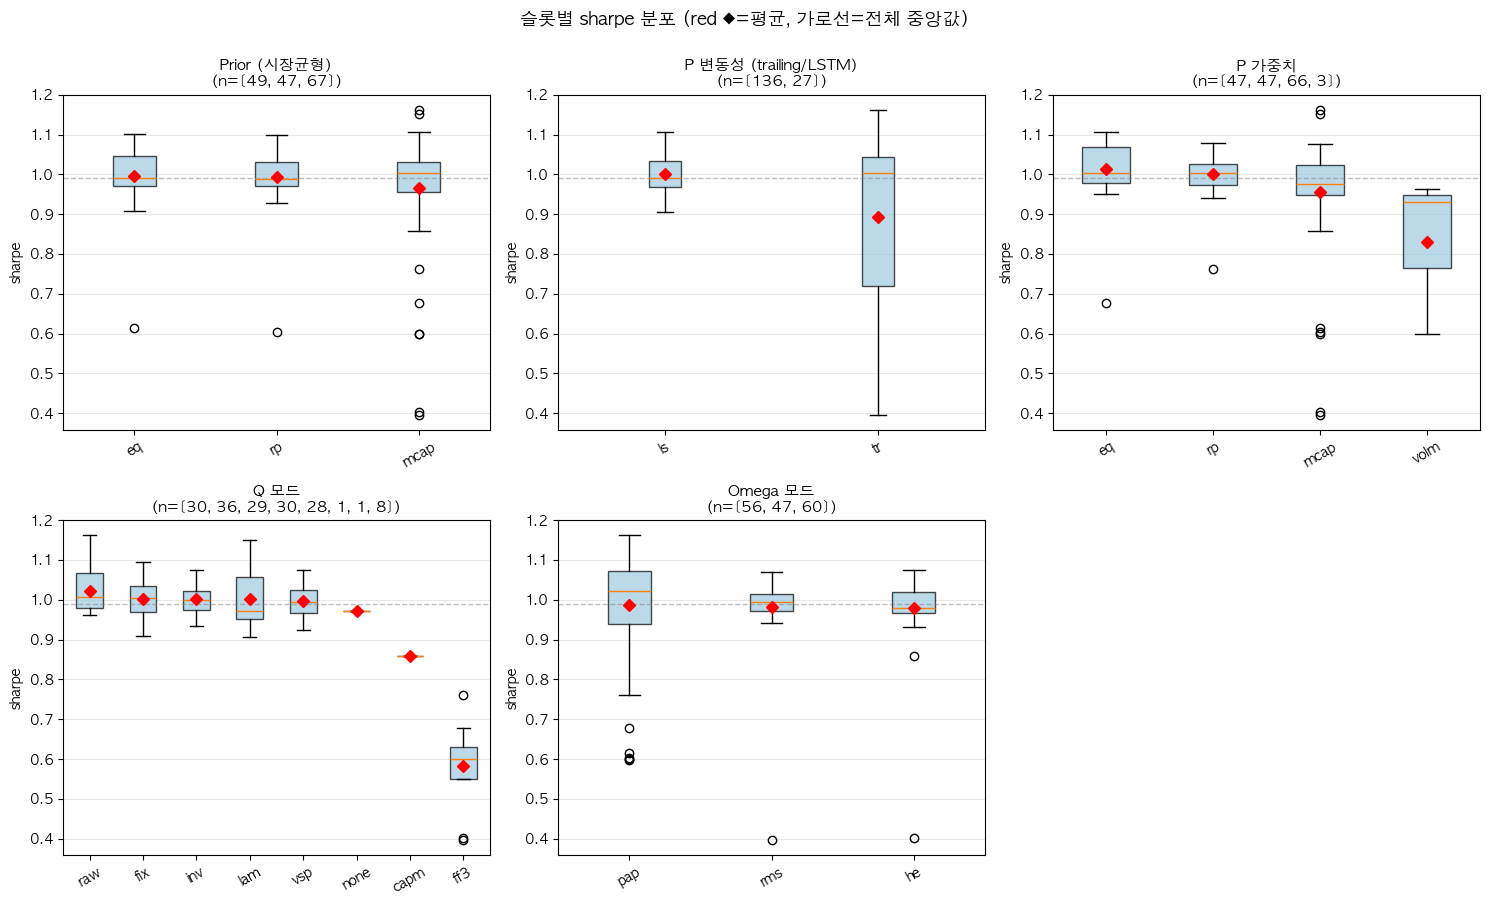

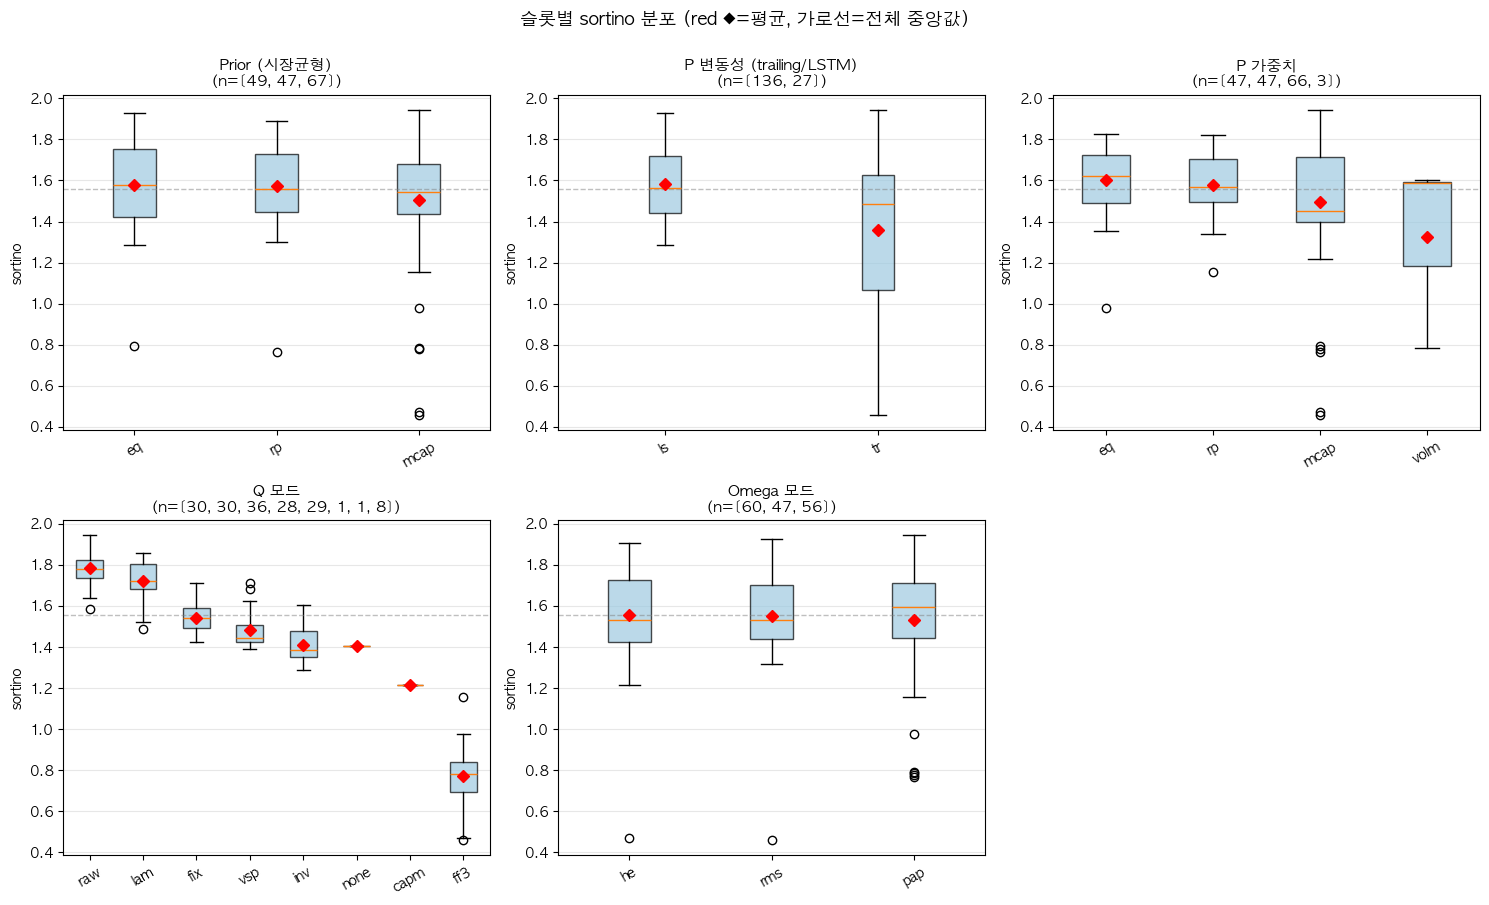

In [266]:
# ── J2. 슬롯별 marginal effect (sharpe + sortino 두 가지 분포) ────
# 어느 슬롯이 metric에 큰 영향? prior_s, p_s, pw_s, q_s, om_s

# ── ① sharpe 분포 ──────────────────────────────────────────
print('■ J2-A. 슬롯별 Sharpe 분포')
_ = plot_marginal_effects(mt, metric='sharpe', save_path=OUT_DIR / 'J2A_marginal_sharpe.png')

print('\n=== 슬롯별 mean Sharpe (높은 순) ===')
for slot in ['prior_s','p_s','pw_s','q_s','om_s']:
    print(f'\n[{slot}]')
    print(slot_summary(mt, slot, 'sharpe'))

# ── ② sortino 분포 ─────────────────────────────────────────
print('\n\n■ J2-B. 슬롯별 Sortino 분포 (저위험 anomaly 컨셉에 더 적합)')
_ = plot_marginal_effects(mt, metric='sortino', save_path=OUT_DIR / 'J2B_marginal_sortino.png')

print('\n=== 슬롯별 mean Sortino (높은 순) ===')
for slot in ['prior_s','p_s','pw_s','q_s','om_s']:
    print(f'\n[{slot}]')
    print(slot_summary(mt, slot, 'sortino'))


## K. 레짐 안정성 분석 — Sortino + 3-레짐 변동성 ⭐

### 왜 이 분석이 필요한가
- **Sharpe보다 Sortino가 본 프로젝트에 더 적합**: 저위험 anomaly 컨셉 → 하방 변동성만이 진짜 손실 위험
- **레짐별 일관성**: 한 시기만 강한 후보는 운. 모든 레짐에서 일관되게 좋은 후보를 찾아야 함
- **MDD 안정성**: 위기 레짐에서 MDD 폭증하는 후보 제외

### 3-레짐 정의 (HMM n=3 구조전환점 기반)

| 레짐 | 기간 | 개월 | 환경 |
|---|---|---:|---|
| R1 회복 | 2010-01 ~ 2012-06 | 30 | Post-GFC + EU위기 |
| R2 확장 | 2012-07 ~ 2019-12 | 90 | 장기 Bull |
| R3 변동 | 2020-01 ~ 2024-12 | 60 | COVID + 22 베어 + AI 랠리 |

### 핵심 지표 (build_regime_table 출력)
- `sortino_R1..R3`: 레짐별 Sortino
- `sortino_mean`: 3 레짐 평균
- `sortino_std`: 3 레짐 표준편차 (**낮을수록 안정**)
- `sortino_ir = sortino_mean / sortino_std`: 변동 대비 평균 (메인 정렬 키)
- `sharpe_ir = sharpe_mean / sharpe_std`: Sharpe 버전 IR
- `mdd_worst`: 3 레짐 중 가장 깊은 MDD


In [ ]:
# ── K1. 레짐 테이블 빌드 + 4-view 정렬 + 비교군 ────────────
import importlib, master_table, analyze_plots
importlib.reload(master_table); importlib.reload(analyze_plots)
import numpy as np, pickle

from master_table import build_regime_table, REGIMES, regime_metrics

rt_full = build_regime_table(mt_full, RESULTS_DIR, rf, regimes=REGIMES)
# Q 민감도 변형 (_q55/_q64/_q70) + winner sweep 변형 (winner_q*, winner_pct*) 제외
# → 일반 슬롯 분석은 baseline q=0.003 / winner default만 사용. M/N에서만 rt_full 사용.
rt = rt_full[~rt_full['name'].str.endswith(('_q55','_q64','_q70'))
             & ~rt_full['name'].str.startswith('winner_')].copy()
print(f'레짐 테이블: {len(rt)}개 실험 × {rt.shape[1]}개 컬럼  (sensitivity 변형 제외)')

# ── 비교군 (SPY + 표준 BL) 5-레짐 종합 메트릭 ────────────────
def _calc_ref(label, ret_series, rf, regimes):
    sortinos, mdds = [], []
    rec = {'canonical': label}
    for lbl, s, e in regimes:
        m = regime_metrics(ret_series, rf, s, e)
        if not np.isnan(m['sortino']): sortinos.append(m['sortino'])
        mdds.append(m['mdd'])
    rec['sortino_mean']    = round(np.mean(sortinos), 3) if sortinos else np.nan
    rec['sortino_std']     = round(np.std(sortinos),  3) if sortinos else np.nan
    rec['mdd_worst']       = round(np.min(mdds),      3) if mdds else np.nan
    return rec

def _load_ret(name):
    with open(RESULTS_DIR / f'{name}.pkl', 'rb') as f:
        return pickle.load(f)['ret'].dropna()

baseline_ret    = _load_ret('mat_mcap_mcap_fix_he')

ref_rows = [
    _calc_ref('SPY (시장 패시브)',          spy_ret,      rf, REGIMES),
    _calc_ref('mat_mcap_mcap_fix_he (표준 BL)', baseline_ret, rf, REGIMES),
]

view_cols = ['canonical','sortino_mean','sortino_std','mdd_worst','sharpe']

print('\n■ 비교군 — 5-레짐 종합')
display(pd.DataFrame([{k: r.get(k, np.nan) for k in view_cols} for r in ref_rows]).round(3))

# ── 비교군 레짐별 상세 (Sortino / Sharpe / MDD) ─────────────────
benchmarks_list = [('SPY', spy_ret), ('mat_mcap_mcap_fix_he', baseline_ret)]

print('\n■ 비교군 레짐별 상세 — Sortino / Sharpe / MDD')

for metric_key, metric_label in [('sortino','Sortino'), ('sharpe','Sharpe'), ('mdd','MDD')]:
    print(f'\n[ {metric_label} per 레짐 ]')
    rows = []
    for name, ret in benchmarks_list:
        rec = {'benchmark': name}
        for lbl, s, e in REGIMES:
            v = regime_metrics(ret, rf, s, e)[metric_key]
            rec[lbl] = v if not pd.isna(v) else np.nan
        rows.append(rec)
    df_m = pd.DataFrame(rows).set_index('benchmark')
    if metric_key == 'mdd':
        display(df_m.style.format('{:.2%}'))
    else:
        display(df_m.round(3))

# ── 4가지 정렬 관점 (각각 Top 5) ─────────────────────────────

print('\n■ ① sortino_mean 정렬  (5 레짐 평균 Sortino 최고)')
display(rt.nlargest(5, 'sortino_mean')[view_cols].round(3))

print('\n■ ② Sortino IR 정렬  (mean / std, 변동 대비 평균)')
rt2 = rt.copy()
rt2['sortino_ir'] = rt2['sortino_mean'] / rt2['sortino_std'].replace(0, np.nan)
display(rt2.nlargest(5, 'sortino_ir')[view_cols + ['sortino_ir']].round(3))

In [ ]:
# ── K2. Sortino IR Top 20 통합 대시보드 ───────────────────────────
import importlib, master_table, analyze_plots
importlib.reload(master_table); importlib.reload(analyze_plots)
from analyze_plots import plot_styled_regime_dashboard

# rt가 K1에서 build됐다고 가정. composite_rank 제거되었으니 다시 빌드.
from master_table import build_regime_table, REGIMES
rt = build_regime_table(mt, RESULTS_DIR, rf, regimes=REGIMES)


# 비교군 레짐별 Sortino
print('■ 레짐별 Sortino — 비교군')
print(f'{"레짐":<12} {"SPY":>7} {"mat_mcap_mcap_fix_he":>22}')
print('-' * 44)
for lbl, s, e in REGIMES:
    sm = regime_metrics(spy_ret,      rf, s, e)['sortino']
    bm = regime_metrics(baseline_ret, rf, s, e)['sortino']
    print(f'{lbl:<12} {sm:>7.2f} {bm:>22.2f}')

# ── K2-A. Sortino IR Top 20 — 3 metric × 3 레짐 통합 대시보드 (PNG) ─
print('\n\n=== K2-A. Sortino IR 정렬 Top 20 대시보드 ===')
print('  → 좌:SORTINO / 가운데:SHARPE / 우:MDD  ·  녹=좋음, 적=나쁨')

_ = plot_styled_regime_dashboard(
    rt, rank_by='sortino_ir', top_n=20,
    save_path=OUT_DIR / 'K2A_sortino_ir_dashboard.png',
)

# 행 매핑 표
top20 = rt.nlargest(20, 'sortino_ir').reset_index(drop=True); top20.index += 1
print('\n■ K2-A 행 매핑 (sortino_ir 큰 순)')
display(top20[['canonical','sortino_ir','sortino_mean','sortino_std','mdd_worst','sharpe']].round(3))


## K2-T. Sortino IR Top 20 — 전체기간 메트릭 표

K2 대시보드 후보(sortino_ir 정렬 Top 20)를 **전체기간 단일 수치**로 정리. 발표·보고용.

메트릭: Sharpe / Sortino / CAGR / 변동성 / MDD / Beta / Alpha (모두 TC 차감 후)

In [ ]:
# ── K2-T. Sortino IR Top 20 — 전체기간 메트릭 표 ───────────────────
# 표시 메트릭: 순위 / 실험명 / Sharpe / Sortino / Sortino_IR / CAGR / Vol / MDD / Beta / Alpha
# Sortino_IR (= sortino_mean / sortino_std, rt에서 가져옴): 3 레짐 안정성 지표
# ⭐ 마커 = K2-X50 composite 1위 winner (eq_ls_eq_lam_pap)

WINNER_NAME = 'eq_ls_eq_lam_pap'

top20_names = rt.nlargest(20, 'sortino_ir')['name'].tolist()
summary = mt[mt['name'].isin(top20_names)].copy()
summary = summary.merge(rt[['name', 'sortino_ir']], on='name', how='left')
summary['_order'] = summary['name'].map({n: i for i, n in enumerate(top20_names)})
summary = summary.sort_values('_order').drop(columns='_order')

# 헤더
header = '=' * 110
sep    = '-' * 110
print(header)
print(f'{"#":>3}  {"실험명":<32}{"Sharpe":>8}{"Sortino":>9}{"Sortino_IR":>11}{"CAGR":>8}{"변동성":>8}{"MDD":>9}{"Beta":>8}{"Alpha":>8}')
print(sep)

# 행 출력 (순위 + winner 마커)
for i, (_, r) in enumerate(summary.iterrows(), start=1):
    canonical = str(r['canonical'])
    is_winner = canonical == WINNER_NAME
    rank_s   = f'{i:>2}.'
    marker   = ' ⭐' if is_winner else '  '
    name_w   = 30 if is_winner else 32
    name     = canonical[:name_w]
    name_f   = f'{name}{marker}' if is_winner else f'{name}'
    sh       = f'{r["sharpe"]:.3f}'
    so       = f'{r["sortino"]:.3f}'
    sir      = f'{r["sortino_ir"]:.2f}'  if pd.notna(r.get('sortino_ir')) else '-'
    cagr     = f'{r["cagr"]*100:.2f}%'
    vol      = f'{r["vol"]*100:.2f}%'
    mdd      = f'{r["mdd"]*100:.2f}%'
    beta     = f'{r["beta"]:.3f}'  if pd.notna(r['beta'])  else '-'
    alpha    = f'{r["alpha"]*100:.2f}%' if pd.notna(r['alpha']) else '-'
    print(f'{rank_s:>3}  {name_f:<32}{sh:>8}{so:>9}{sir:>11}{cagr:>8}{vol:>8}{mdd:>9}{beta:>8}{alpha:>8}')

print(header)

# 비교군
print('\n■ 비교군 — 전체기간')
print(sep)
print(f'{"#":>3}  {"실험명":<32}{"Sharpe":>8}{"Sortino":>9}{"Sortino_IR":>11}{"CAGR":>8}{"변동성":>8}{"MDD":>9}{"Beta":>8}{"Alpha":>8}')
print(sep)
for nm in ['mat_mcap_mcap_fix_he']:
    r = mt[mt['name']==nm].iloc[0]
    rt_r = rt[rt['name']==nm]
    sir_v = rt_r['sortino_ir'].iloc[0] if len(rt_r)>0 and pd.notna(rt_r['sortino_ir'].iloc[0]) else None
    sir   = f'{sir_v:.2f}' if sir_v is not None else '-'
    beta  = f'{r["beta"]:.3f}' if pd.notna(r['beta']) else '-'
    alpha = f'{r["alpha"]*100:.2f}%' if pd.notna(r['alpha']) else '-'
    print(f'{"":>3}  {nm[:31]:<32}{r["sharpe"]:>8.3f}{r["sortino"]:>9.3f}{sir:>11}{r["cagr"]*100:>7.2f}%{r["vol"]*100:>7.2f}%{r["mdd"]*100:>8.2f}%{beta:>8}{alpha:>8}')

# SPY
from bl_functions import compute_metrics
from master_table import REGIMES as _REGIMES_K2T
spy_m = compute_metrics(spy_ret, rf, label='SPY', mkt_ret=spy_ret)
_spy_sortinos = []
for _lbl, _s, _e in _REGIMES_K2T:
    _seg = spy_ret.loc[_s:_e]
    if len(_seg) >= 3:
        _m = compute_metrics(_seg, rf.reindex(_seg.index).fillna(0), label='SPY', mkt_ret=_seg)
        if pd.notna(_m.get('sortino')):
            _spy_sortinos.append(_m['sortino'])
_spy_sir = np.mean(_spy_sortinos) / np.std(_spy_sortinos) if len(_spy_sortinos) >= 2 and np.std(_spy_sortinos) > 0 else None
_spy_sir_s = f'{_spy_sir:.2f}' if _spy_sir is not None else '-'
print(f'{"":>3}  {"SPY":<32}{spy_m["sharpe"]:>8.3f}{spy_m["sortino"]:>9.3f}{_spy_sir_s:>11}{spy_m["cagr"]*100:>7.2f}%{spy_m["vol"]*100:>7.2f}%{spy_m["mdd"]*100:>8.2f}%{"-":>8}{"-":>8}')
print(header)


## K2-TF. CAGR 높은 순 Top 20 — 전체기간 메트릭 표 (rms + trailing + volm 제외)

K2-T 기본 정렬은 다양한 변형이 섞여 후보 비교가 어려움 → 운용성·일관성 관점에서 다음 세 조건을 추가로 적용한 후 **CAGR이 높은**(연환산 수익률 큰) 순서로 Top 20 + 전체기간 메트릭을 보여준다:

- omega_mode `rms` (`rmse`, 예측오차 RMSE 기반 적응형) **제외** → 신뢰성 부족
- p_mode `tr`/`tr252` (trailing 변동성 기반 P) **제외** → LSTM 슬롯(`ls`)만 유지
- p_weight `volm` (`vol_mcap`, sparse 변형) **제외**

정렬 기준은 `cagr`(전 기간 연환산 수익률) — `nlargest`로 가장 큰 값부터 정렬해 **공격적 수익(고수익)** 관점에서 후보를 본다. K2-T 코드는 그대로 두고 비교용으로 추가.

In [ ]:
# ── K2-TF. CAGR 높은 순 Top 20 — 전체기간 메트릭 표 ──────
# K2-T와 동일 로직, 정렬 기준: cagr (전체기간 연환산 수익률) — 높은 순
# (옛 rms/trailing/volm 필터는 2026-05-11 슬롯 정리로 불필요 — 모두 제거됨)

rt_filt = rt.copy()

# cagr는 mt에 있으므로 mt로부터 정렬 후보 추출
mt_filt = mt[mt['name'].isin(rt_filt['name'])].copy()
top20_names_tf = mt_filt.nlargest(20, 'cagr')['name'].tolist()
summary_tf = mt[mt['name'].isin(top20_names_tf)].copy()
summary_tf = summary_tf.merge(rt_filt[['name', 'sortino_ir']], on='name', how='left')
summary_tf['_order'] = summary_tf['name'].map({n: i for i, n in enumerate(top20_names_tf)})
summary_tf = summary_tf.sort_values('_order').drop(columns='_order')

print(f'   후보: rt {len(rt_filt)}개 (Top 20 추출 모집단, 정렬기준=cagr 높은 순)')
print()

header = '=' * 110
sep    = '-' * 110
print(header)
print(f'{"#":>3}  {"실험명":<32}{"Sharpe":>8}{"Sortino":>9}{"Sortino_IR":>11}{"CAGR":>8}{"변동성":>8}{"MDD":>9}{"Beta":>8}{"Alpha":>8}')
print(sep)

for i, (_, r) in enumerate(summary_tf.iterrows(), start=1):
    canonical = str(r['canonical'])
    rank_s   = f'{i:>2}.'
    name     = canonical[:32]
    sh       = f'{r["sharpe"]:.3f}'
    so       = f'{r["sortino"]:.3f}'
    sir      = f'{r["sortino_ir"]:.2f}'  if pd.notna(r.get('sortino_ir')) else '-'
    cagr     = f'{r["cagr"]*100:.2f}%'
    vol      = f'{r["vol"]*100:.2f}%'
    mdd      = f'{r["mdd"]*100:.2f}%'
    beta     = f'{r["beta"]:.3f}'  if pd.notna(r['beta'])  else '-'
    alpha    = f'{r["alpha"]*100:.2f}%' if pd.notna(r['alpha']) else '-'
    print(f'{rank_s:>3}  {name:<32}{sh:>8}{so:>9}{sir:>11}{cagr:>8}{vol:>8}{mdd:>9}{beta:>8}{alpha:>8}')

print(header)

# 비교군 4종 (K2-T와 동일)
print('\n■ 비교군 — 전체기간')
print(sep)
print(f'{"#":>3}  {"실험명":<32}{"Sharpe":>8}{"Sortino":>9}{"Sortino_IR":>11}{"CAGR":>8}{"변동성":>8}{"MDD":>9}{"Beta":>8}{"Alpha":>8}')
print(sep)
for nm in ['mat_mcap_mcap_fix_he']:
    r = mt[mt['name']==nm].iloc[0]
    rt_r = rt[rt['name']==nm]
    sir_v = rt_r['sortino_ir'].iloc[0] if len(rt_r)>0 and pd.notna(rt_r['sortino_ir'].iloc[0]) else None
    sir   = f'{sir_v:.2f}' if sir_v is not None else '-'
    beta  = f'{r["beta"]:.3f}' if pd.notna(r['beta']) else '-'
    alpha = f'{r["alpha"]*100:.2f}%' if pd.notna(r['alpha']) else '-'
    print(f'{"":>3}  {nm[:31]:<32}{r["sharpe"]:>8.3f}{r["sortino"]:>9.3f}{sir:>11}{r["cagr"]*100:>7.2f}%{r["vol"]*100:>7.2f}%{r["mdd"]*100:>8.2f}%{beta:>8}{alpha:>8}')

# SPY
from bl_functions import compute_metrics
from master_table import REGIMES as _REGIMES_K2TF
spy_m = compute_metrics(spy_ret, rf, label='SPY', mkt_ret=spy_ret)
_spy_sortinos = []
for _lbl, _s, _e in _REGIMES_K2TF:
    _seg = spy_ret.loc[_s:_e]
    if len(_seg) >= 3:
        _m = compute_metrics(_seg, rf.reindex(_seg.index).fillna(0), label='SPY', mkt_ret=_seg)
        if pd.notna(_m.get('sortino')):
            _spy_sortinos.append(_m['sortino'])
_spy_sir = np.mean(_spy_sortinos) / np.std(_spy_sortinos) if len(_spy_sortinos) >= 2 and np.std(_spy_sortinos) > 0 else None
_spy_sir_s = f'{_spy_sir:.2f}' if _spy_sir is not None else '-'
print(f'{"":>3}  {"SPY":<32}{spy_m["sharpe"]:>8.3f}{spy_m["sortino"]:>9.3f}{_spy_sir_s:>11}{spy_m["cagr"]*100:>7.2f}%{spy_m["vol"]*100:>7.2f}%{spy_m["mdd"]*100:>8.2f}%{"-":>8}{"-":>8}')
print(header)


## K2-M. 전체기간 Sortino 정렬 Top 20 × 3 metric 히트맵

`sortino_ir`(mean/std, 변동 대비 평균) 정렬과 별개로 **전체기간 단일 Sortino** (`mt['sortino']`, 2010–2024를 하나의 시계열로 본 값) 기준 Top 20.

→ "안정성"이나 "레짐 평균"이 아니라 **전 기간 통합 위험조정 수익률**이 가장 큰 후보.
→ K2-A(sortino_ir) / 여기(전체기간 Sortino) / K2-H(sharpe_ir) 3 관점 비교 가능.


=== K2-M. 전체기간 Sortino 정렬 Top 20 대시보드 ===
  → 좌:SORTINO / 가운데:SHARPE / 우:MDD  ·  녹=좋음, 적=나쁨

■ K2-M 행 매핑 (전체기간 sortino 큰 순)


,canonical,sortino_full,sortino_mean,sortino_ir,mdd_worst,sharpe
1,mcap_tr_mcap_raw_pap,1.944,2.169,3.01,-0.144,1.162
2,eq_ls_mcap_raw_rms,1.927,1.947,10.52,-0.140,1.069
3,eq_ls_mcap_raw_he,1.905,1.928,8.20,-0.142,1.060
4,rp_ls_mcap_raw_rms,1.891,1.985,4.94,-0.140,1.049
5,rp_ls_mcap_raw_he,1.884,1.982,4.48,-0.144,1.044
6,eq_tr_mcap_raw_he,1.864,1.951,5.04,-0.148,1.076
7,eq_ls_mcap_lam_rms,1.859,1.908,10.54,-0.129,1.045
8,eq_ls_mcap_lam_he,1.850,1.898,8.29,-0.122,1.034
9,rp_ls_mcap_lam_he,1.850,1.970,4.44,-0.126,1.020
10,rp_ls_mcap_lam_rms,1.843,1.962,4.95,-0.133,1.029



■ 전체기간 Sortino Top 20 ∩ Sortino IR Top 20 = 통합 우위·안정성 모두 강한 후보
  교집합: 4개


,canonical,sortino_full,sortino_ir,sortino_mean,mdd_worst,sharpe
1,eq_ls_mcap_raw_rms,1.927,10.52,1.947,-0.140,1.069
6,eq_ls_mcap_lam_rms,1.859,10.54,1.908,-0.129,1.045
12,eq_ls_eq_raw_pap,1.826,16.50,1.963,-0.136,1.096
16,eq_ls_eq_lam_pap,1.816,15.98,1.918,-0.136,1.102


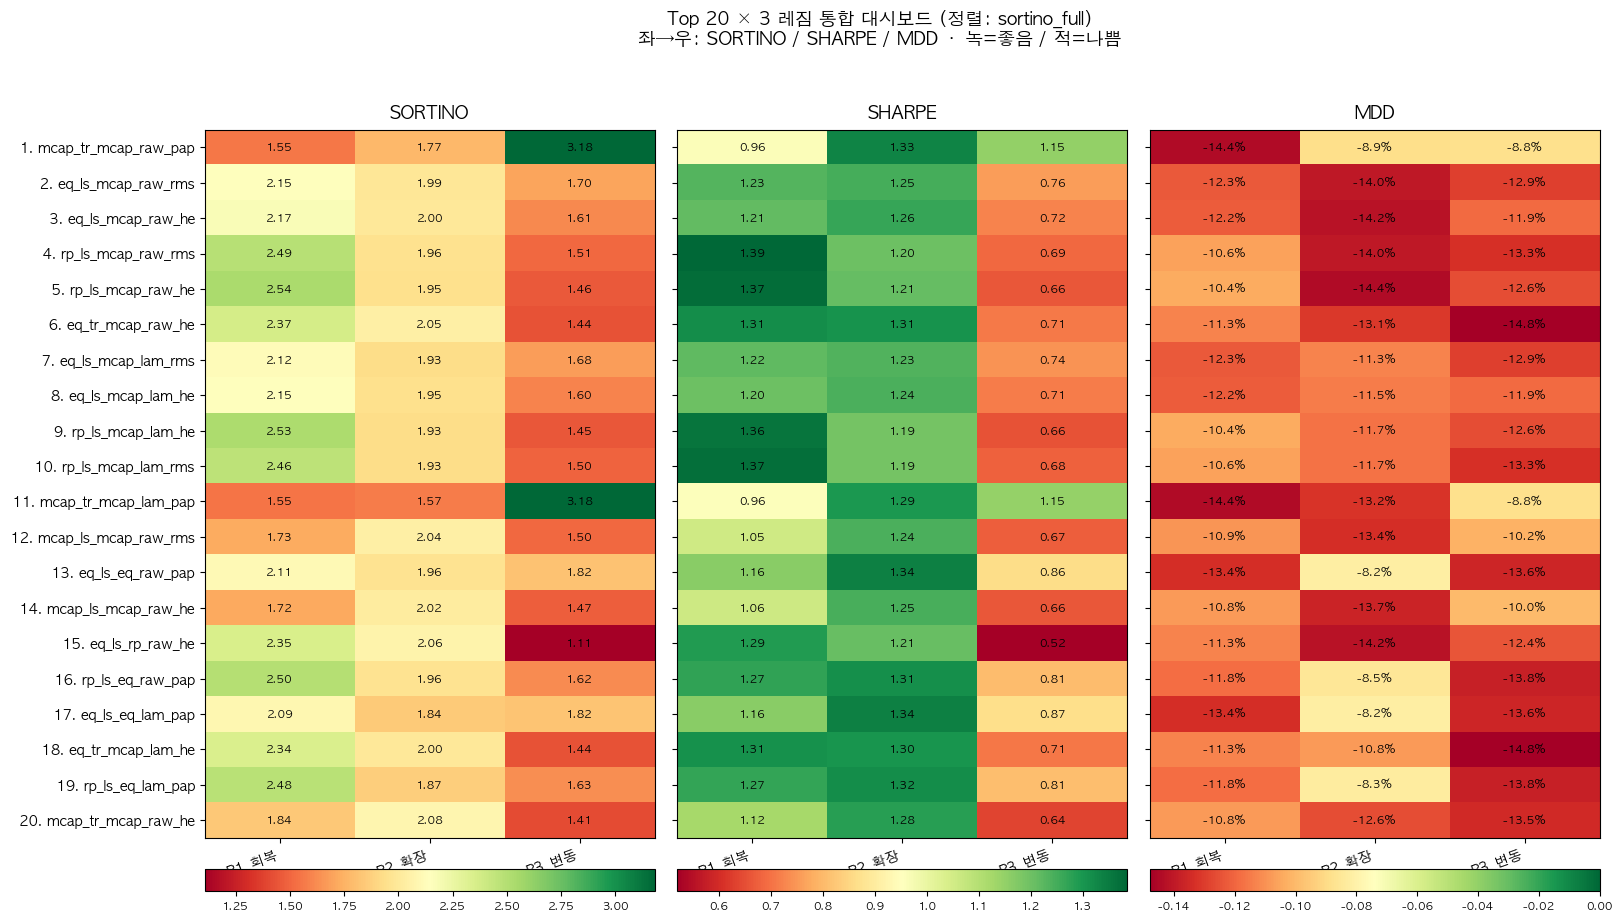

In [271]:
# ── K2-M. 전체기간 Sortino Top 20 통합 대시보드 + 두 정렬 교집합 ─────
import importlib, master_table, analyze_plots
importlib.reload(master_table); importlib.reload(analyze_plots)
from analyze_plots import plot_styled_regime_dashboard

print('=== K2-M. 전체기간 Sortino 정렬 Top 20 대시보드 ===')
print('  → 좌:SORTINO / 가운데:SHARPE / 우:MDD  ·  녹=좋음, 적=나쁨')

# rt에 mt의 전체기간 sortino를 병합 → 그 컬럼으로 정렬
rt_sm = rt.merge(mt[['name','sortino']].rename(columns={'sortino':'sortino_full'}),
                 on='name', how='left')

_ = plot_styled_regime_dashboard(
    rt_sm, rank_by='sortino_full', top_n=20,
    save_path=OUT_DIR / 'K2M_sortino_full_dashboard.png',
)

top20_sm = rt_sm.nlargest(20, 'sortino_full').reset_index(drop=True); top20_sm.index += 1
print('\n■ K2-M 행 매핑 (전체기간 sortino 큰 순)')
display(top20_sm[['canonical','sortino_full','sortino_mean','sortino_ir','mdd_worst','sharpe']].round(3))

# 전체기간 Sortino Top 20 ∩ Sortino IR Top 20 = 단순 평균·안정성 모두 강한 후보
print('\n■ 전체기간 Sortino Top 20 ∩ Sortino IR Top 20 = 통합 우위·안정성 모두 강한 후보')
set_sf = set(top20_sm['canonical'])
set_si = set(rt.nlargest(20, 'sortino_ir')['canonical'])
inter_sf_si = set_sf & set_si
print(f'  교집합: {len(inter_sf_si)}개')
if inter_sf_si:
    display(rt_sm[rt_sm['canonical'].isin(inter_sf_si)].sort_values('sortino_full', ascending=False)
              [['canonical','sortino_full','sortino_ir','sortino_mean','mdd_worst','sharpe']]
              .round(3))


## K2-MT. 전체기간 Sortino Top 20 — 전체기간 메트릭 표

K2-M 대시보드 후보(전체기간 `mt['sortino']` 정렬 Top 20)를 **전체기간 단일 수치**로 정리. 정렬 기준과 표시 기준이 일치하므로 Sortino 컬럼이 단조 감소.

메트릭: Sharpe / Sortino / CAGR / 변동성 / MDD / Beta / Alpha (모두 TC 차감 후)


In [ ]:
# ── K2-MT. 전체기간 Sortino Top 20 — 전체기간 메트릭 표 ───────────────
# 표시 메트릭: Sharpe / Sortino / Sortino_IR / CAGR / 변동성(Vol) / MDD / Beta / Alpha
# 정렬 기준 = 표시되는 Sortino 컬럼과 동일 (mt['sortino']) → 단조 감소
# Sortino_IR은 rt에서 병합 (안정성 지표 동시 표시)

top20_sm_names = mt.nlargest(20, 'sortino')['name'].tolist()
summary_sm = mt[mt['name'].isin(top20_sm_names)].copy()
# rt에서 sortino_ir 병합
summary_sm = summary_sm.merge(rt[['name', 'sortino_ir']], on='name', how='left')
# 정렬 순서 유지
summary_sm['_order'] = summary_sm['name'].map({n: i for i, n in enumerate(top20_sm_names)})
summary_sm = summary_sm.sort_values('_order').drop(columns='_order')

# 헤더
header = '=' * 102
sep    = '-' * 102
print(header)
print(f'{"실험명":<32}{"Sharpe":>8}{"Sortino":>9}{"Sortino_IR":>11}{"CAGR":>8}{"변동성":>8}{"MDD":>9}{"Beta":>8}{"Alpha":>8}')
print(sep)

# 행 출력 (canonical 표시)
for _, r in summary_sm.iterrows():
    name   = r['canonical'][:31]
    sh     = f'{r["sharpe"]:.3f}'
    so     = f'{r["sortino"]:.3f}'
    sir    = f'{r["sortino_ir"]:.2f}'  if pd.notna(r.get('sortino_ir')) else '-'
    cagr   = f'{r["cagr"]*100:.2f}%'
    vol    = f'{r["vol"]*100:.2f}%'
    mdd    = f'{r["mdd"]*100:.2f}%'
    beta   = f'{r["beta"]:.3f}'  if pd.notna(r['beta'])  else '-'
    alpha  = f'{r["alpha"]*100:.2f}%' if pd.notna(r['alpha']) else '-'
    print(f'{name:<32}{sh:>8}{so:>9}{sir:>11}{cagr:>8}{vol:>8}{mdd:>9}{beta:>8}{alpha:>8}')

print(header)

# 비교군도 함께 (참고)
print('\n■ 비교군 — 전체기간')
print(sep)
print(f'{"실험명":<32}{"Sharpe":>8}{"Sortino":>9}{"Sortino_IR":>11}{"CAGR":>8}{"변동성":>8}{"MDD":>9}{"Beta":>8}{"Alpha":>8}')
print(sep)
for nm in ['mat_mcap_mcap_fix_he']:
    r = mt[mt['name']==nm].iloc[0]
    rt_r = rt[rt['name']==nm]
    sir_val = rt_r['sortino_ir'].iloc[0] if len(rt_r) > 0 and pd.notna(rt_r['sortino_ir'].iloc[0]) else None
    name   = nm[:31]
    sh     = f'{r["sharpe"]:.3f}'
    so     = f'{r["sortino"]:.3f}'
    sir    = f'{sir_val:.2f}' if sir_val is not None else '-'
    cagr   = f'{r["cagr"]*100:.2f}%'
    vol    = f'{r["vol"]*100:.2f}%'
    mdd    = f'{r["mdd"]*100:.2f}%'
    beta   = f'{r["beta"]:.3f}'  if pd.notna(r['beta'])  else '-'
    alpha  = f'{r["alpha"]*100:.2f}%' if pd.notna(r['alpha']) else '-'
    print(f'{name:<32}{sh:>8}{so:>9}{sir:>11}{cagr:>8}{vol:>8}{mdd:>9}{beta:>8}{alpha:>8}')

# SPY 별도 계산
from bl_functions import compute_metrics
from master_table import REGIMES as _REGIMES_K2MT
spy_m = compute_metrics(spy_ret, rf, label='SPY', mkt_ret=spy_ret)
_spy_sortinos = []
for _lbl, _s, _e in _REGIMES_K2MT:
    _seg = spy_ret.loc[_s:_e]
    if len(_seg) >= 3:
        _m = compute_metrics(_seg, rf.reindex(_seg.index).fillna(0), label='SPY', mkt_ret=_seg)
        if pd.notna(_m.get('sortino')):
            _spy_sortinos.append(_m['sortino'])
_spy_sir = np.mean(_spy_sortinos) / np.std(_spy_sortinos) if len(_spy_sortinos) >= 2 and np.std(_spy_sortinos) > 0 else None
_spy_sir_s = f'{_spy_sir:.2f}' if _spy_sir is not None else '-'
print(f'{"SPY":<32}{spy_m["sharpe"]:>8.3f}{spy_m["sortino"]:>9.3f}{_spy_sir_s:>11}{spy_m["cagr"]*100:>7.2f}%{spy_m["vol"]*100:>7.2f}%{spy_m["mdd"]*100:>8.2f}%{"-":>8}{"-":>8}')
print(header)


## K2-X50. Sortino IR ∩ 전체기간 Sortino Top 50 — 확장 교집합

K2-X(Top 20 교집합)는 양쪽 기준 모두에서 상위 12.8% 안에 든 후보만 잡아 매우 보수적.
Top 50으로 넓히면 (전체 ~156개 중 32%) **"두 관점에서 모두 평균 이상"인 robust 후보군**을 더 풍부하게 확보.

→ 후보 풀 확장으로 슬롯 패턴(prior/p/q/omega)의 안정 영역을 더 잘 드러냄.


In [ ]:
# ── K2-X50. Sortino IR ∩ 전체기간 Sortino Top 50 — 확장 교집합 ─────
# K2-X와 동일 로직, 단 N=50으로 확장.
import importlib, master_table, analyze_plots
importlib.reload(master_table); importlib.reload(analyze_plots)
from analyze_plots import plot_styled_regime_dashboard

N = 50
top50_si_names = set(rt.nlargest(N, 'sortino_ir')['name'])
top50_sf_names = set(rt_sm.nlargest(N, 'sortino_full')['name'])
inter50_names  = top50_si_names & top50_sf_names
n_inter50      = len(inter50_names)

print(f'■ 교집합 크기: {n_inter50}개 (sortino_ir Top{N} ∩ sortino_full Top{N})')
print(f'  · sortino_ir만 Top{N}: {len(top50_si_names - top50_sf_names)}개')
print(f'  · sortino_full만 Top{N}: {len(top50_sf_names - top50_si_names)}개')
print(f'  · 둘 다 Top{N}: {n_inter50}개')

if n_inter50 == 0:
    print('  → 교집합 없음.')
else:
    rt_inter50 = rt_sm[rt_sm['name'].isin(inter50_names)].copy()

    # ── (1) 히트맵 대시보드 ──────────────────────────────────────
    print(f'\n=== K2-X50-A. 교집합 {n_inter50}개 — 3 metric × 3 레짐 히트맵 (sortino_full 정렬) ===')
    print('  → 좌:SORTINO / 가운데:SHARPE / 우:MDD  ·  녹=좋음, 적=나쁨')
    _ = plot_styled_regime_dashboard(
        rt_inter50, rank_by='sortino_full', top_n=n_inter50,
        save_path=OUT_DIR / 'K2X50_intersection_dashboard.png',
    )

    # 행 매핑 (pkl name 포함)
    inter50_top = rt_inter50.nlargest(n_inter50, 'sortino_full').reset_index(drop=True); inter50_top.index += 1
    print(f'\n■ K2-X50 행 매핑 (sortino_full 큰 순)')
    display(inter50_top[['name','canonical','sortino_full','sortino_ir','sortino_mean','sortino_std','mdd_worst','sharpe']].round(3))

    # ── (2) 전체기간 메트릭 표 (pkl 파일명 + canonical 같이) ─────
    # Sortino_IR 컬럼 추가 (rt에서 병합)
    print(f'\n=== K2-X50-B. 교집합 {n_inter50}개 — 전체기간 메트릭 표 ===')
    inter50_ordered = rt_inter50.nlargest(n_inter50, 'sortino_full')['name'].tolist()
    summary50 = mt[mt['name'].isin(inter50_ordered)].copy()
    summary50 = summary50.merge(rt[['name', 'sortino_ir']], on='name', how='left')
    summary50['_order'] = summary50['name'].map({n: i for i, n in enumerate(inter50_ordered)})
    summary50 = summary50.sort_values('_order').drop(columns='_order')

    header = '=' * 134
    sep    = '-' * 134
    print(header)
    print(f'{"pkl":<32}{"canonical":<32}{"Sharpe":>8}{"Sortino":>9}{"Sortino_IR":>11}{"CAGR":>8}{"변동성":>8}{"MDD":>9}{"Beta":>8}{"Alpha":>8}')
    print(sep)
    for _, r in summary50.iterrows():
        pkl    = str(r['name'])[:31]
        canon  = str(r['canonical'])[:31]
        sh     = f'{r["sharpe"]:.3f}'
        so     = f'{r["sortino"]:.3f}'
        sir    = f'{r["sortino_ir"]:.2f}'  if pd.notna(r.get('sortino_ir')) else '-'
        cagr   = f'{r["cagr"]*100:.2f}%'
        vol    = f'{r["vol"]*100:.2f}%'
        mdd    = f'{r["mdd"]*100:.2f}%'
        beta   = f'{r["beta"]:.3f}'  if pd.notna(r['beta'])  else '-'
        alpha  = f'{r["alpha"]*100:.2f}%' if pd.notna(r['alpha']) else '-'
        print(f'{pkl:<32}{canon:<32}{sh:>8}{so:>9}{sir:>11}{cagr:>8}{vol:>8}{mdd:>9}{beta:>8}{alpha:>8}')
    print(header)

    # 비교군도 함께 (참고)
    print('\n■ 비교군 — 전체기간')
    print(sep)
    print(f'{"pkl":<32}{"canonical":<32}{"Sharpe":>8}{"Sortino":>9}{"Sortino_IR":>11}{"CAGR":>8}{"변동성":>8}{"MDD":>9}{"Beta":>8}{"Alpha":>8}')
    print(sep)
    for nm in ['mat_mcap_mcap_fix_he']:
        r = mt[mt['name']==nm].iloc[0]
        rt_r = rt[rt['name']==nm]
        sir_val = rt_r['sortino_ir'].iloc[0] if len(rt_r) > 0 and pd.notna(rt_r['sortino_ir'].iloc[0]) else None
        pkl    = nm[:31]
        canon  = str(r['canonical'])[:31]
        sh     = f'{r["sharpe"]:.3f}'
        so     = f'{r["sortino"]:.3f}'
        sir    = f'{sir_val:.2f}' if sir_val is not None else '-'
        cagr   = f'{r["cagr"]*100:.2f}%'
        vol    = f'{r["vol"]*100:.2f}%'
        mdd    = f'{r["mdd"]*100:.2f}%'
        beta   = f'{r["beta"]:.3f}'  if pd.notna(r['beta'])  else '-'
        alpha  = f'{r["alpha"]*100:.2f}%' if pd.notna(r['alpha']) else '-'
        print(f'{pkl:<32}{canon:<32}{sh:>8}{so:>9}{sir:>11}{cagr:>8}{vol:>8}{mdd:>9}{beta:>8}{alpha:>8}')

    from bl_functions import compute_metrics
    from master_table import REGIMES as _REGIMES_K2X50
    spy_m = compute_metrics(spy_ret, rf, label='SPY', mkt_ret=spy_ret)
    _spy_sortinos = []
    for _lbl, _s, _e in _REGIMES_K2X50:
        _seg = spy_ret.loc[_s:_e]
        if len(_seg) >= 3:
            _m = compute_metrics(_seg, rf.reindex(_seg.index).fillna(0), label='SPY', mkt_ret=_seg)
            if pd.notna(_m.get('sortino')):
                _spy_sortinos.append(_m['sortino'])
    _spy_sir = np.mean(_spy_sortinos) / np.std(_spy_sortinos) if len(_spy_sortinos) >= 2 and np.std(_spy_sortinos) > 0 else None
    _spy_sir_s = f'{_spy_sir:.2f}' if _spy_sir is not None else '-'
    print(f'{"SPY":<32}{"(market passive)":<32}{spy_m["sharpe"]:>8.3f}{spy_m["sortino"]:>9.3f}{_spy_sir_s:>11}{spy_m["cagr"]*100:>7.2f}%{spy_m["vol"]*100:>7.2f}%{spy_m["mdd"]*100:>8.2f}%{"-":>8}{"-":>8}')
    print(header)

    # ── (3) 슬롯 패턴 빠른 집계 ──────────────────────────────────
    print(f'\n=== K2-X50-C. 교집합 {n_inter50}개 슬롯 패턴 ===')
    for slot in ['prior_s','p_s','pw_s','q_s','om_s']:
        if slot in summary50.columns:
            vc = summary50[slot].value_counts()
            print(f'  [{slot}] ' + ' / '.join(f'{k}={v}' for k,v in vc.items()))


## K2-SI. Sharpe IR Top 20 통합 대시보드 (Sortino-IR Top 20과 동등 비교)

`sortino_ir`(K2-A) 정렬과 별개로 **`sharpe_ir = sharpe_mean / sharpe_std`** 기준으로 Top 20 추출.
3 metric (sortino, sharpe, mdd) per 레짐 히트맵으로 시각화.

→ Sortino 안정성(K2-A) ↔ Sharpe 안정성(K2-SI) 두 측면 동시 점검.

In [ ]:
# ── K2-SI. Sharpe IR Top 20 통합 대시보드 ───────────────────────
import importlib, master_table, analyze_plots
importlib.reload(master_table); importlib.reload(analyze_plots)
from analyze_plots import plot_styled_regime_dashboard

# 비교군 레짐별 Sharpe
print('■ 레짐별 Sharpe — 비교군')
print(f'{"레짐":<12} {"SPY":>7} {"mat_mcap_mcap_fix_he":>22}')
print('-' * 44)
for lbl, s, e in REGIMES:
    sm = regime_metrics(spy_ret,      rf, s, e)['sharpe']
    bm = regime_metrics(baseline_ret, rf, s, e)['sharpe']
    print(f'{lbl:<12} {sm:>7.2f} {bm:>22.2f}')

print('\n\n=== K2-SI. Sharpe IR 정렬 Top 20 대시보드 ===')
print('  → 좌:SORTINO / 가운데:SHARPE / 우:MDD  ·  녹=좋음, 적=나쁨')

_ = plot_styled_regime_dashboard(
    rt, rank_by='sharpe_ir', top_n=20,
    save_path=OUT_DIR / 'K2SI_sharpe_ir_dashboard.png',
)

top20_sh = rt.nlargest(20, 'sharpe_ir').reset_index(drop=True); top20_sh.index += 1
print('\n■ K2-SI 행 매핑 (sharpe_ir 큰 순)')
display(top20_sh[['canonical','sharpe_ir','sharpe_mean','sharpe_std','sortino_ir','mdd_worst']].round(3))

# Sortino IR ∩ Sharpe IR Top 20 교집합
print('\n■ Sortino IR Top 20 ∩ Sharpe IR Top 20 = 두 측면 모두 강한 후보')
set_so = set(rt.nlargest(20, 'sortino_ir')['canonical'])
set_sh = set(top20_sh['canonical'])
inter_ir = set_so & set_sh
print(f'  교집합: {len(inter_ir)}개')
if inter_ir:
    display(rt[rt['canonical'].isin(inter_ir)].sort_values('sortino_ir', ascending=False)
              [['canonical','sortino_ir','sharpe_ir','sortino_mean','mdd_worst','sharpe']]
              .round(3))


## K2-SIT. Sharpe IR Top 20 — 전체기간 메트릭 표

K2-SI 대시보드 후보(sharpe_ir 정렬 Top 20)를 **전체기간 단일 수치**로 정리. 발표·보고용.

메트릭: Sharpe / Sortino / Sharpe_IR / CAGR / 변동성 / MDD / Beta / Alpha (모두 TC 차감 후)

In [ ]:
# ── K2-SIT. Sharpe IR Top 20 — 전체기간 메트릭 표 ──────────────────
# 표시 메트릭: Sharpe / Sortino / Sharpe_IR / CAGR / 변동성(Vol) / MDD / Beta / Alpha
# Sharpe_IR (= sharpe_mean / sharpe_std, rt에서 가져옴): 3 레짐 안정성 지표

top20_sh_names = rt.nlargest(20, 'sharpe_ir')['name'].tolist()
summary_sh = mt[mt['name'].isin(top20_sh_names)].copy()
summary_sh = summary_sh.merge(rt[['name', 'sharpe_ir']], on='name', how='left')
summary_sh['_order'] = summary_sh['name'].map({n: i for i, n in enumerate(top20_sh_names)})
summary_sh = summary_sh.sort_values('_order').drop(columns='_order')

header = '=' * 102
sep    = '-' * 102
print(header)
print(f'{"실험명":<32}{"Sharpe":>8}{"Sortino":>9}{"Sharpe_IR":>11}{"CAGR":>8}{"변동성":>8}{"MDD":>9}{"Beta":>8}{"Alpha":>8}')
print(sep)

for _, r in summary_sh.iterrows():
    name   = r['canonical'][:31]
    sh     = f'{r["sharpe"]:.3f}'
    so     = f'{r["sortino"]:.3f}'
    shir   = f'{r["sharpe_ir"]:.2f}'  if pd.notna(r.get('sharpe_ir')) else '-'
    cagr   = f'{r["cagr"]*100:.2f}%'
    vol    = f'{r["vol"]*100:.2f}%'
    mdd    = f'{r["mdd"]*100:.2f}%'
    beta   = f'{r["beta"]:.3f}'  if pd.notna(r['beta'])  else '-'
    alpha  = f'{r["alpha"]*100:.2f}%' if pd.notna(r['alpha']) else '-'
    print(f'{name:<32}{sh:>8}{so:>9}{shir:>11}{cagr:>8}{vol:>8}{mdd:>9}{beta:>8}{alpha:>8}')
print(header)

# 비교군
print('\n■ 비교군 — 전체기간')
print(sep)
print(f'{"실험명":<32}{"Sharpe":>8}{"Sortino":>9}{"Sharpe_IR":>11}{"CAGR":>8}{"변동성":>8}{"MDD":>9}{"Beta":>8}{"Alpha":>8}')
print(sep)
for nm in ['mat_mcap_mcap_fix_he']:
    r = mt[mt['name']==nm].iloc[0]
    rt_r = rt[rt['name']==nm]
    shir_val = rt_r['sharpe_ir'].iloc[0] if len(rt_r) > 0 and pd.notna(rt_r['sharpe_ir'].iloc[0]) else None
    print(f'{nm[:31]:<32}{r["sharpe"]:>8.3f}{r["sortino"]:>9.3f}'
          f'{(f"{shir_val:.2f}" if shir_val is not None else "-"):>11}'
          f'{r["cagr"]*100:>7.2f}%{r["vol"]*100:>7.2f}%{r["mdd"]*100:>8.2f}%'
          f'{(f"{r["beta"]:.3f}" if pd.notna(r["beta"]) else "-"):>8}'
          f'{(f"{r["alpha"]*100:.2f}%" if pd.notna(r["alpha"]) else "-"):>8}')

# SPY
from bl_functions import compute_metrics
spy_m = compute_metrics(spy_ret, rf, label='SPY', mkt_ret=spy_ret)
_spy_sharpes = []
for _lbl, _s, _e in REGIMES:
    _seg = spy_ret.loc[_s:_e]
    if len(_seg) >= 3:
        _m = compute_metrics(_seg, rf.reindex(_seg.index).fillna(0), label='SPY', mkt_ret=_seg)
        if pd.notna(_m.get('sharpe')):
            _spy_sharpes.append(_m['sharpe'])
_spy_shir = np.mean(_spy_sharpes) / np.std(_spy_sharpes) if len(_spy_sharpes) >= 2 and np.std(_spy_sharpes) > 0 else None
_spy_shir_s = f'{_spy_shir:.2f}' if _spy_shir is not None else '-'
print(f'{"SPY":<32}{spy_m["sharpe"]:>8.3f}{spy_m["sortino"]:>9.3f}{_spy_shir_s:>11}{spy_m["cagr"]*100:>7.2f}%{spy_m["vol"]*100:>7.2f}%{spy_m["mdd"]*100:>8.2f}%{"-":>8}{"-":>8}')
print(header)


## K2-SF. 전체기간 Sharpe 정렬 Top 20 × 3 metric 히트맵

`sharpe_ir`(mean/std, K2-SI) 정렬과 별개로 **전체기간 단일 Sharpe** (`mt['sharpe']`, 168m 통합) 기준 Top 20.

→ "안정성"이나 "레짐 평균"이 아니라 **전 기간 통합 위험조정 수익률**이 가장 큰 후보.
→ K2-A(sortino_ir) / K2-M(전체 sortino) / K2-SI(sharpe_ir) / 여기(전체 sharpe) 4 관점 비교.

=== K2-SF. 전체기간 Sharpe 정렬 Top 20 대시보드 ===
  → 좌:SORTINO / 가운데:SHARPE / 우:MDD  ·  녹=좋음, 적=나쁨

■ K2-SF 행 매핑 (전체기간 sharpe 큰 순)


,canonical,sharpe_full,sharpe_mean,sharpe_ir,mdd_worst,sortino
1,mcap_tr_mcap_raw_pap,1.162,1.148,7.55,-0.144,1.944
2,mcap_tr_mcap_lam_pap,1.151,1.133,8.27,-0.144,1.841
3,mcap_ls_eq_lam_pap,1.106,1.100,6.43,-0.147,1.742
4,eq_ls_eq_lam_pap,1.102,1.122,5.75,-0.136,1.816
5,rp_ls_eq_lam_pap,1.099,1.131,4.94,-0.138,1.808
6,mcap_ls_eq_raw_pap,1.099,1.100,6.51,-0.147,1.775
7,eq_ls_eq_raw_pap,1.096,1.122,5.72,-0.136,1.826
8,rp_ls_eq_fix_pap,1.096,1.142,5.39,-0.121,1.711
9,rp_ls_eq_raw_pap,1.093,1.130,4.91,-0.138,1.819
10,eq_ls_eq_fix_pap,1.091,1.120,7.32,-0.127,1.709



■ 전체기간 Sharpe Top 20 ∩ Sharpe IR Top 20 = 통합 우위·안정성 모두 강한 후보
  교집합: 4개


,canonical,sharpe_full,sharpe_ir,sharpe_mean,mdd_worst,sortino
0,mcap_tr_mcap_raw_pap,1.162,7.55,1.148,-0.144,1.944
10,mcap_tr_mcap_lam_pap,1.151,8.27,1.133,-0.144,1.841
44,eq_ls_eq_fix_pap,1.091,7.32,1.120,-0.127,1.709
63,mcap_ls_eq_fix_pap,1.073,7.78,1.082,-0.137,1.624


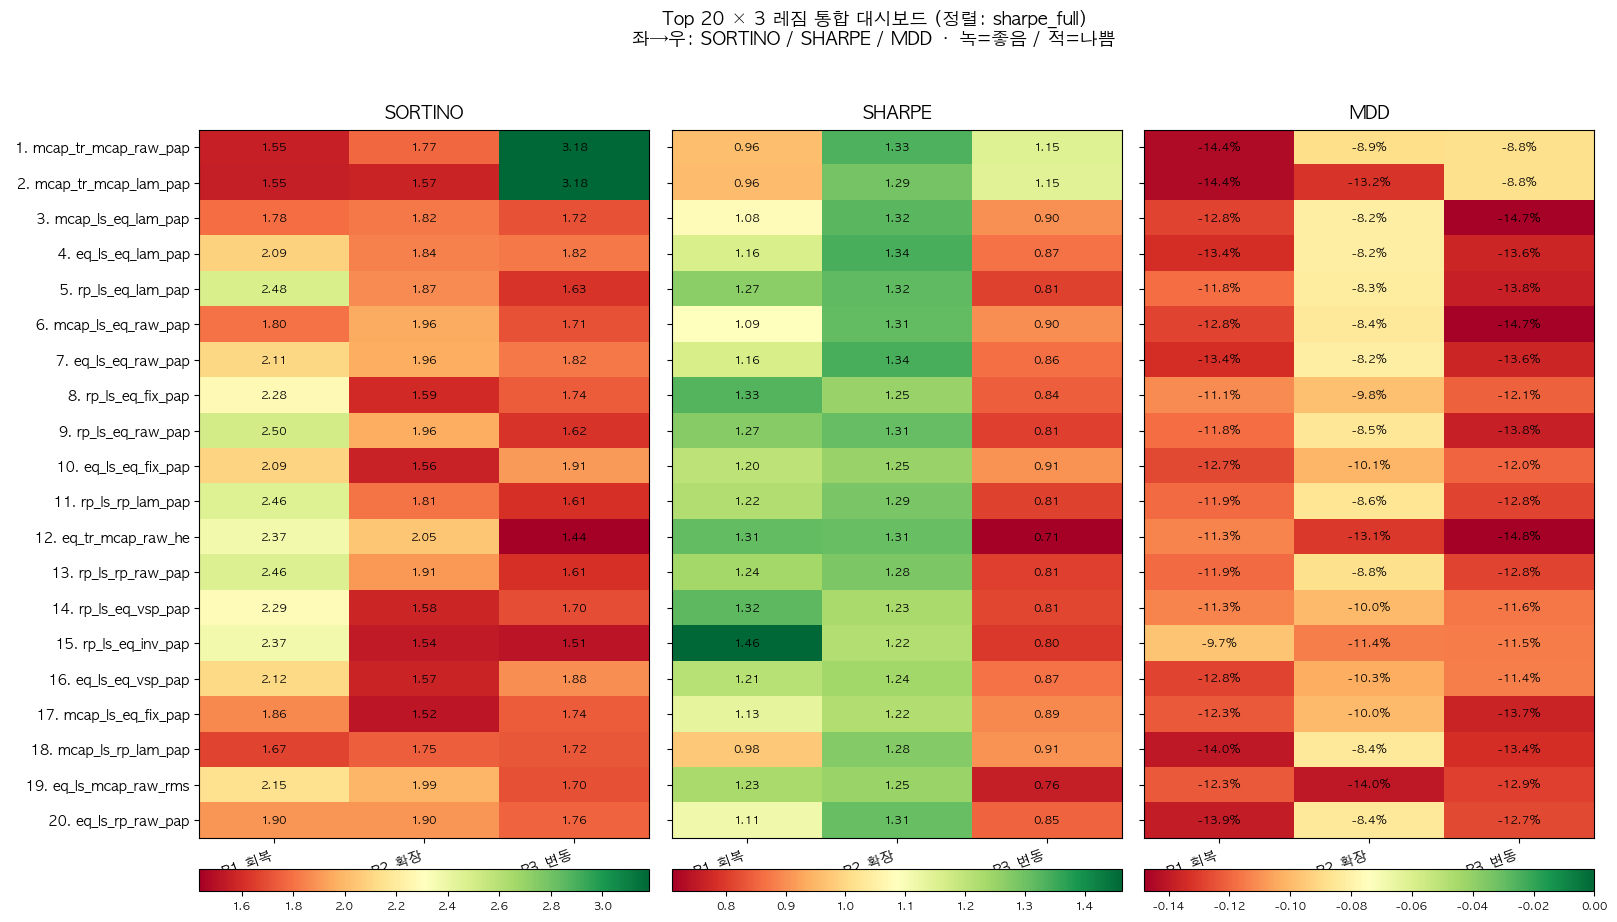

In [276]:
# ── K2-SF. 전체기간 Sharpe Top 20 통합 대시보드 + 두 정렬 교집합 ─────
import importlib, master_table, analyze_plots
importlib.reload(master_table); importlib.reload(analyze_plots)
from analyze_plots import plot_styled_regime_dashboard

print('=== K2-SF. 전체기간 Sharpe 정렬 Top 20 대시보드 ===')
print('  → 좌:SORTINO / 가운데:SHARPE / 우:MDD  ·  녹=좋음, 적=나쁨')

# rt에 mt의 전체기간 sharpe를 sharpe_full로 병합
rt_shf = rt.merge(mt[['name','sharpe']].rename(columns={'sharpe':'sharpe_full'}),
                  on='name', how='left')

_ = plot_styled_regime_dashboard(
    rt_shf, rank_by='sharpe_full', top_n=20,
    save_path=OUT_DIR / 'K2SF_sharpe_full_dashboard.png',
)

top20_shf = rt_shf.nlargest(20, 'sharpe_full').reset_index(drop=True); top20_shf.index += 1
print('\n■ K2-SF 행 매핑 (전체기간 sharpe 큰 순)')
display(top20_shf[['canonical','sharpe_full','sharpe_mean','sharpe_ir','mdd_worst','sortino']].round(3))

# 전체기간 Sharpe Top 20 ∩ Sharpe IR Top 20 = 통합 우위·안정성 모두 강한 후보
print('\n■ 전체기간 Sharpe Top 20 ∩ Sharpe IR Top 20 = 통합 우위·안정성 모두 강한 후보')
set_shf = set(top20_shf['canonical'])
set_shir = set(rt.nlargest(20, 'sharpe_ir')['canonical'])
inter_shf_shir = set_shf & set_shir
print(f'  교집합: {len(inter_shf_shir)}개')
if inter_shf_shir:
    display(rt_shf[rt_shf['canonical'].isin(inter_shf_shir)].sort_values('sharpe_full', ascending=False)
              [['canonical','sharpe_full','sharpe_ir','sharpe_mean','mdd_worst','sortino']]
              .round(3))


## K2-SFT. 전체기간 Sharpe Top 20 — 전체기간 메트릭 표

K2-SF 대시보드 후보(전체기간 `mt['sharpe']` 정렬 Top 20)를 **전체기간 단일 수치**로 정리. 정렬 기준과 표시 기준이 일치하므로 Sharpe 컬럼이 단조 감소.

메트릭: Sharpe / Sortino / Sharpe_IR / CAGR / 변동성 / MDD / Beta / Alpha (모두 TC 차감 후)

In [ ]:
# ── K2-SFT. 전체기간 Sharpe Top 20 — 전체기간 메트릭 표 ───────────────
# 표시 메트릭: Sharpe / Sortino / Sharpe_IR / CAGR / 변동성(Vol) / MDD / Beta / Alpha
# 정렬 기준 = 표시되는 Sharpe 컬럼과 동일 (mt['sharpe']) → 단조 감소

top20_shf_names = mt.nlargest(20, 'sharpe')['name'].tolist()
summary_shf = mt[mt['name'].isin(top20_shf_names)].copy()
summary_shf = summary_shf.merge(rt[['name', 'sharpe_ir']], on='name', how='left')
summary_shf['_order'] = summary_shf['name'].map({n: i for i, n in enumerate(top20_shf_names)})
summary_shf = summary_shf.sort_values('_order').drop(columns='_order')

header = '=' * 102
sep    = '-' * 102
print(header)
print(f'{"실험명":<32}{"Sharpe":>8}{"Sortino":>9}{"Sharpe_IR":>11}{"CAGR":>8}{"변동성":>8}{"MDD":>9}{"Beta":>8}{"Alpha":>8}')
print(sep)

for _, r in summary_shf.iterrows():
    name   = r['canonical'][:31]
    sh     = f'{r["sharpe"]:.3f}'
    so     = f'{r["sortino"]:.3f}'
    shir   = f'{r["sharpe_ir"]:.2f}'  if pd.notna(r.get('sharpe_ir')) else '-'
    cagr   = f'{r["cagr"]*100:.2f}%'
    vol    = f'{r["vol"]*100:.2f}%'
    mdd    = f'{r["mdd"]*100:.2f}%'
    beta   = f'{r["beta"]:.3f}'  if pd.notna(r['beta'])  else '-'
    alpha  = f'{r["alpha"]*100:.2f}%' if pd.notna(r['alpha']) else '-'
    print(f'{name:<32}{sh:>8}{so:>9}{shir:>11}{cagr:>8}{vol:>8}{mdd:>9}{beta:>8}{alpha:>8}')
print(header)

# 비교군
print('\n■ 비교군 — 전체기간')
print(sep)
print(f'{"실험명":<32}{"Sharpe":>8}{"Sortino":>9}{"Sharpe_IR":>11}{"CAGR":>8}{"변동성":>8}{"MDD":>9}{"Beta":>8}{"Alpha":>8}')
print(sep)
for nm in ['mat_mcap_mcap_fix_he']:
    r = mt[mt['name']==nm].iloc[0]
    rt_r = rt[rt['name']==nm]
    shir_val = rt_r['sharpe_ir'].iloc[0] if len(rt_r) > 0 and pd.notna(rt_r['sharpe_ir'].iloc[0]) else None
    print(f'{nm[:31]:<32}{r["sharpe"]:>8.3f}{r["sortino"]:>9.3f}'
          f'{(f"{shir_val:.2f}" if shir_val is not None else "-"):>11}'
          f'{r["cagr"]*100:>7.2f}%{r["vol"]*100:>7.2f}%{r["mdd"]*100:>8.2f}%'
          f'{(f"{r["beta"]:.3f}" if pd.notna(r["beta"]) else "-"):>8}'
          f'{(f"{r["alpha"]*100:.2f}%" if pd.notna(r["alpha"]) else "-"):>8}')

# SPY
from bl_functions import compute_metrics
spy_m = compute_metrics(spy_ret, rf, label='SPY', mkt_ret=spy_ret)
_spy_sharpes = []
for _lbl, _s, _e in REGIMES:
    _seg = spy_ret.loc[_s:_e]
    if len(_seg) >= 3:
        _m = compute_metrics(_seg, rf.reindex(_seg.index).fillna(0), label='SPY', mkt_ret=_seg)
        if pd.notna(_m.get('sharpe')):
            _spy_sharpes.append(_m['sharpe'])
_spy_shir = np.mean(_spy_sharpes) / np.std(_spy_sharpes) if len(_spy_sharpes) >= 2 and np.std(_spy_sharpes) > 0 else None
_spy_shir_s = f'{_spy_shir:.2f}' if _spy_shir is not None else '-'
print(f'{"SPY":<32}{spy_m["sharpe"]:>8.3f}{spy_m["sortino"]:>9.3f}{_spy_shir_s:>11}{spy_m["cagr"]*100:>7.2f}%{spy_m["vol"]*100:>7.2f}%{spy_m["mdd"]*100:>8.2f}%{"-":>8}{"-":>8}')
print(header)


## L. 전체 슬롯 메트릭 CSV 내보내기

K_CUT (2010-01 ~ 2023-12) 기준으로 **162개 슬롯 × 모든 핵심 지표**를 CSV로 출력. SHAP·회귀 없이 슬롯값의 한계효과를 비교하기 위한 raw data.

**산출 파일** (모두 `outputs/05b_analyze/`):

| 파일 | 내용 | 용도 |
|---|---|---|
| `all_slots_full_metrics.csv` | 전체기간 단일 지표 (Sharpe·Sortino·Sortino_IR·CAGR·Vol·MDD·Beta·Alpha·Turnover…) | "어느 슬롯값이 평균적으로 좋은가" — Excel 피벗으로 슬롯별 mean 비교 |
| `all_slots_regime_metrics.csv` | 3 레짐별 Sortino·Sharpe·MDD + 안정성 요약 | "어느 슬롯값이 어느 레짐에서 좋은가" — 레짐 일관성 점검 |

**slot 분해 컬럼 포함** (`prior_s, p_s, pw_s, q_s, om_s`) — Excel에서 GROUP BY로 q_mode='lam' 슬롯의 평균 sortino 같은 한계효과 즉시 산출 가능.


In [279]:
# ── L1. 전체 슬롯 × 전체기간 메트릭 CSV ────────────────────────────
# Sortino 내림차순 정렬, 162개 슬롯 모두 포함
# 컬럼: name + canonical + slot 분해 + 전체기간 위험조정 지표

# rt에서 sortino_ir 가져와 mt에 병합 (mt에는 없음)
full_export = mt.merge(
    rt[['name', 'sortino_ir', 'sortino_mean', 'sortino_std']],
    on='name', how='left'
).copy()

# 컬럼 선택 + 순서 정리
slot_cols = ['prior_s', 'p_s', 'pw_s', 'q_s', 'om_s']
slot_cols = [c for c in slot_cols if c in full_export.columns]

metric_cols = [
    'sharpe', 'sortino', 'sortino_ir', 'sortino_mean', 'sortino_std',
    'cagr', 'vol', 'mdd', 'calmar',
    'beta', 'alpha',
    'win_rate', 'cvar_5', 'mdd_duration',
    'turnover_avg', 'eff_n_avg', 'n_months',
]
metric_cols = [c for c in metric_cols if c in full_export.columns]

ordered = ['name', 'canonical'] + slot_cols + metric_cols
full_export = full_export[ordered].sort_values('sortino', ascending=False).reset_index(drop=True)

# 가독성: 비율은 4자리, 퍼센트성 (cagr/vol/mdd/alpha 등) 그대로 (decimal)
for c in ['sharpe', 'sortino', 'sortino_ir', 'sortino_mean', 'sortino_std',
          'calmar', 'beta', 'win_rate', 'eff_n_avg', 'turnover_avg']:
    if c in full_export.columns:
        full_export[c] = full_export[c].round(4)
for c in ['cagr', 'vol', 'mdd', 'alpha', 'cvar_5']:
    if c in full_export.columns:
        full_export[c] = full_export[c].round(6)

# 저장
out_path = OUT_DIR / 'all_slots_full_metrics.csv'
full_export.to_csv(out_path, index=False, encoding='utf-8-sig')
print(f'✓ 저장: {out_path.relative_to(Path.cwd())}')
print(f'  shape: {full_export.shape}  ·  정렬: sortino 내림차순')
print(f'  컬럼: {list(full_export.columns)}')

# 미리보기 Top 10
print(f'\n■ 미리보기 (Sortino Top 10)')
display(full_export.head(10))

# 슬롯별 한계효과 빠른 요약 (Excel 피벗 없이도 보이게)
print(f'\n■ 슬롯값별 한계효과 — 평균 Sortino (162개 전체)')
for slot in slot_cols:
    g = full_export.groupby(slot)['sortino'].agg(['mean', 'count']).round(3).sort_values('mean', ascending=False)
    g.columns = ['mean_sortino', 'n']
    print(f'\n  [{slot}]')
    print(g.to_string())


✓ 저장: outputs/05b_analyze/all_slots_full_metrics.csv
  shape: (163, 24)  ·  정렬: sortino 내림차순
  컬럼: ['name', 'canonical', 'prior_s', 'p_s', 'pw_s', 'q_s', 'om_s', 'sharpe', 'sortino', 'sortino_ir', 'sortino_mean', 'sortino_std', 'cagr', 'vol', 'mdd', 'calmar', 'beta', 'alpha', 'win_rate', 'cvar_5', 'mdd_duration', 'turnover_avg', 'eff_n_avg', 'n_months']

■ 미리보기 (Sortino Top 10)


,name,canonical,prior_s,p_s,pw_s,q_s,om_s,sharpe,sortino,sortino_ir,...,mdd,calmar,beta,alpha,win_rate,cvar_5,mdd_duration,turnover_avg,eff_n_avg,n_months
0,paperctx_q_raw,mcap_tr_mcap_raw_pap,mcap,tr,mcap,raw,pap,1.162,1.944,3.01,...,-0.1435,1.094,0.699,0.0554,0.661,-0.0646,11,0.9891,58.8923,168
1,mat_eq_mcap_raw_rms,eq_ls_mcap_raw_rms,eq,ls,mcap,raw,rms,1.069,1.927,10.52,...,-0.1404,0.983,0.535,0.0591,0.625,-0.0585,14,0.4409,47.9151,168
2,mat_eq_mcap_raw_he,eq_ls_mcap_raw_he,eq,ls,mcap,raw,he,1.060,1.905,8.20,...,-0.1419,0.967,0.541,0.0577,0.619,-0.0589,14,0.4298,52.2569,168
3,mat_rp_mcap_raw_rms,rp_ls_mcap_raw_rms,rp,ls,mcap,raw,rms,1.049,1.891,4.94,...,-0.1401,0.944,0.503,0.0579,0.625,-0.0582,14,0.4264,43.7256,168
4,mat_rp_mcap_raw_he,rp_ls_mcap_raw_he,rp,ls,mcap,raw,he,1.044,1.884,4.48,...,-0.1437,0.919,0.506,0.0574,0.619,-0.0584,14,0.4190,47.4072,168
5,prior_eq_q_raw_lam,eq_tr_mcap_raw_he,eq,tr,mcap,raw,he,1.076,1.864,5.04,...,-0.1479,0.924,0.545,0.0563,0.649,-0.0595,14,0.6985,48.3837,168
6,mat_eq_mcap_lam_rms,eq_ls_mcap_lam_rms,eq,ls,mcap,lam,rms,1.045,1.859,10.54,...,-0.1289,1.025,0.551,0.0515,0.619,-0.0588,14,0.4512,47.9600,168
7,mat_eq_mcap_lam_he,eq_ls_mcap_lam_he,eq,ls,mcap,lam,he,1.034,1.850,8.29,...,-0.1217,1.076,0.556,0.0499,0.619,-0.0590,14,0.4393,52.1034,168
8,mat_rp_mcap_lam_he,rp_ls_mcap_lam_he,rp,ls,mcap,lam,he,1.020,1.850,4.44,...,-0.1258,1.003,0.519,0.0500,0.619,-0.0582,14,0.4297,47.4034,168
9,mat_rp_mcap_lam_rms,rp_ls_mcap_lam_rms,rp,ls,mcap,lam,rms,1.029,1.843,4.95,...,-0.1333,0.954,0.517,0.0512,0.625,-0.0583,14,0.4402,44.0408,168



■ 슬롯값별 한계효과 — 평균 Sortino (162개 전체)

  [prior_s]
         mean_sortino   n
prior_s                  
eq              1.580  49
rp              1.572  47
mcap            1.503  67

  [p_s]
     mean_sortino    n
p_s                   
ls          1.584  136
tr          1.356   27

  [pw_s]
      mean_sortino   n
pw_s                  
eq           1.602  47
rp           1.580  47
mcap         1.493  66
volm         1.324   3

  [q_s]
      mean_sortino   n
q_s                   
raw          1.784  30
lam          1.723  30
fix          1.543  36
vsp          1.485  28
inv          1.411  29
none         1.407   1
capm         1.216   1
ff3          0.773   8

  [om_s]
      mean_sortino   n
om_s                  
he           1.555  60
rms          1.553  47
pap          1.532  56


In [280]:
# ── L2. 전체 슬롯 × 레짐별 메트릭 CSV ──────────────────────────────
# rt: 162개 슬롯 × 레짐별 Sortino/Sharpe/MDD + 안정성 요약 컬럼

# rt에는 이미 모든 레짐 메트릭이 들어있음
slot_cols = ['prior_s', 'p_s', 'pw_s', 'q_s', 'om_s']
slot_cols = [c for c in slot_cols if c in rt.columns]

# 레짐별 컬럼 (build_regime_table이 산출하는 표준 컬럼명)
regime_cols = []
for lbl, _, _ in REGIMES:
    for m in ['sortino', 'sharpe', 'mdd']:
        col = f'{m}_{lbl}'
        if col in rt.columns:
            regime_cols.append(col)

# 안정성 요약 컬럼
summary_cols = [c for c in ['sortino_mean', 'sortino_std', 'sortino_ir',
                            'sharpe_mean', 'sharpe_std', 'sharpe_ir',
                            'mdd_worst'] if c in rt.columns]

ordered = ['name', 'canonical'] + slot_cols + summary_cols + regime_cols
ordered = [c for c in ordered if c in rt.columns]
regime_export = rt[ordered].sort_values('sortino_ir', ascending=False).reset_index(drop=True)

# 라운딩
for c in regime_export.select_dtypes(include='number').columns:
    if 'mdd' in c.lower() or 'cagr' in c.lower():
        regime_export[c] = regime_export[c].round(6)
    else:
        regime_export[c] = regime_export[c].round(4)

# 저장
out_path = OUT_DIR / 'all_slots_regime_metrics.csv'
regime_export.to_csv(out_path, index=False, encoding='utf-8-sig')
print(f'✓ 저장: {out_path.relative_to(Path.cwd())}')
print(f'  shape: {regime_export.shape}  ·  정렬: sortino_ir 내림차순')
print(f'  컬럼 수: {len(regime_export.columns)}')

# 미리보기 Top 10
print(f'\n■ 미리보기 (Sortino_IR Top 10)')
display(regime_export.head(10))

# 슬롯값별 레짐별 한계효과 — 평균 Sortino_IR
print(f'\n■ 슬롯값별 한계효과 — 평균 Sortino_IR (162개 전체)')
for slot in slot_cols:
    g = regime_export.groupby(slot)['sortino_ir'].agg(['mean', 'count']).round(2).sort_values('mean', ascending=False)
    g.columns = ['mean_sortino_ir', 'n']
    print(f'\n  [{slot}]')
    print(g.to_string())

# 레짐별 평균 Sortino — 어느 슬롯이 어느 레짐에서 강한가
print(f'\n■ 슬롯값 × 레짐 평균 Sortino (heatmap-friendly)')
for slot in slot_cols:
    cols_to_show = [f'sortino_{lbl}' for lbl, _, _ in REGIMES if f'sortino_{lbl}' in regime_export.columns]
    if not cols_to_show:
        continue
    g = regime_export.groupby(slot)[cols_to_show].mean().round(3)
    print(f'\n  [{slot}]')
    print(g.to_string())


✓ 저장: outputs/05b_analyze/all_slots_regime_metrics.csv
  shape: (163, 23)  ·  정렬: sortino_ir 내림차순
  컬럼 수: 23

■ 미리보기 (Sortino_IR Top 10)


,name,canonical,prior_s,p_s,pw_s,q_s,om_s,sortino_mean,sortino_std,sortino_ir,...,mdd_worst,sortino_R1_회복,sharpe_R1_회복,mdd_R1_회복,sortino_R2_확장,sharpe_R2_확장,mdd_R2_확장,sortino_R3_변동,sharpe_R3_변동,mdd_R3_변동
0,mat_mcap_rp_lam_pap,mcap_ls_rp_lam_pap,mcap,ls,rp,lam,pap,1.715,0.030,57.17,...,-0.140,1.674,0.976,-0.140,1.747,1.276,-0.084,1.724,0.906,-0.134
1,mat_mcap_eq_lam_pap,mcap_ls_eq_lam_pap,mcap,ls,eq,lam,pap,1.774,0.045,39.42,...,-0.147,1.785,1.076,-0.128,1.823,1.321,-0.082,1.715,0.903,-0.147
2,mat_eq_rp_lam_pap,eq_ls_rp_lam_pap,eq,ls,rp,lam,pap,1.802,0.052,34.65,...,-0.139,1.875,1.098,-0.139,1.765,1.292,-0.083,1.765,0.851,-0.127
3,mat_eq_rp_raw_pap,eq_ls_rp_raw_pap,eq,ls,rp,raw,pap,1.851,0.062,29.85,...,-0.139,1.895,1.114,-0.139,1.895,1.307,-0.084,1.762,0.849,-0.127
4,mat_mcap_rp_raw_pap,mcap_ls_rp_raw_pap,mcap,ls,rp,raw,pap,1.761,0.080,22.01,...,-0.140,1.689,0.985,-0.140,1.872,1.271,-0.086,1.721,0.904,-0.134
5,mat_mcap_eq_raw_pap,mcap_ls_eq_raw_pap,mcap,ls,eq,raw,pap,1.823,0.103,17.70,...,-0.147,1.801,1.086,-0.128,1.959,1.314,-0.084,1.711,0.900,-0.147
6,mat_eq_eq_raw_pap,eq_ls_eq_raw_pap,eq,ls,eq,raw,pap,1.963,0.119,16.50,...,-0.136,2.109,1.164,-0.134,1.962,1.339,-0.082,1.818,0.864,-0.136
7,mat_eq_eq_lam_pap,eq_ls_eq_lam_pap,eq,ls,eq,lam,pap,1.918,0.120,15.98,...,-0.136,2.088,1.162,-0.134,1.845,1.339,-0.082,1.821,0.866,-0.136
8,mat_mcap_rp_vsp_pap,mcap_ls_rp_vsp_pap,mcap,ls,rp,vsp,pap,1.628,0.120,13.57,...,-0.140,1.729,1.034,-0.131,1.459,1.162,-0.117,1.695,0.852,-0.140
9,mat_mcap_eq_vsp_pap,mcap_ls_eq_vsp_pap,mcap,ls,eq,vsp,pap,1.694,0.130,13.03,...,-0.137,1.850,1.116,-0.125,1.532,1.212,-0.100,1.701,0.876,-0.137



■ 슬롯값별 한계효과 — 평균 Sortino_IR (162개 전체)

  [prior_s]
         mean_sortino_ir   n
prior_s                     
mcap                7.09  67
eq                  6.23  49
rp                  3.88  47

  [p_s]
     mean_sortino_ir    n
p_s                      
ls              6.13  136
tr              4.77   27

  [pw_s]
      mean_sortino_ir   n
pw_s                     
rp               6.81  47
eq               5.83  47
mcap             5.39  66
volm             4.50   3

  [q_s]
      mean_sortino_ir   n
q_s                      
lam              9.24  30
raw              7.17  30
capm             6.87   1
none             4.91   1
fix              4.86  36
vsp              4.70  28
inv              4.34  29
ff3              3.28   8

  [om_s]
      mean_sortino_ir   n
om_s                     
pap              9.72  56
rms              3.93  47
he               3.90  60

■ 슬롯값 × 레짐 평균 Sortino (heatmap-friendly)

  [prior_s]
         sortino_R1_회복  sortino_R2_확장  sortino_R3_변동
prior_s

## M. Winner Sensitivity Analysis (in-code, pkl 없이)

**목적**: 90 매트릭스 슬롯 중 winner 식별 → 그 winner 의 `q_value` 와 `pct_group` 민감도를 in-notebook 으로 sweep.

**왜 in-code?** 02b 의 임계값 민감도와 동일 패턴.
- pkl 영구화 불필요 (winner 가 바뀌면 자동 재계산)
- `bl_runner.walk_forward()` 가 `monthly_cache` 를 재사용 → 슬롯당 약 30초~1분
- 17개 sweep 슬롯 = 약 10~15분

**선행 조건**:
- 04_BL_Walkforward 가 90 매트릭스 pkl 생성 완료
- 본 노트북에서 mt_full, rt_full 이미 빌드됨


In [ ]:
# ── M0. Winner 식별 + bl_runner 환경 셋업 ────────────────────────
# Winner 기준: sortino_ir (rt_full 의 통합 메트릭) 1위
from bl_runner import load_lstm_pred, build_monthly_cache, walk_forward
from bl_config import EXPERIMENTS, BASELINE

# (a) Winner 자동 식별
winner_name = rt_full.sort_values('sortino_ir', ascending=False).iloc[0]['name']
winner_cfg  = next((c for c in EXPERIMENTS if c['name'] == winner_name), None)
if winner_cfg is None:
    raise ValueError(f'winner {winner_name} 가 EXPERIMENTS 에 없음 — bl_config.py 확인')

print(f'★ Winner (sortino_ir 1위): {winner_name}')
print(f'  config: prior={winner_cfg["prior"]}, p_weight={winner_cfg["p_weight"]}, '
      f'q={winner_cfg["q_mode"]}, omega={winner_cfg["omega_mode"]}, '
      f'q_value={winner_cfg.get("q_value", 0.003)}')

# (b) BL 환경 1회 셋업 (panel, lstm, monthly_cache) — 후속 sweep 에서 재사용
import pickle as _pkl
PANEL_DIR  = Path('data')
panel_sens = pd.read_csv(PANEL_DIR / 'monthly_panel.csv', parse_dates=['date']).set_index(['date', 'ticker'])
daily_ret_sens = pd.read_pickle(PANEL_DIR / 'daily_returns.pkl')

all_dates_sens  = panel_sens.index.get_level_values('date').unique().sort_values()
pred_dates_sens = all_dates_sens[all_dates_sens >= '2010-01-01']
spy_sens = panel_sens['spy_ret'].groupby(level='date').first()
rf_sens  = panel_sens['rf_1m'].groupby(level='date').first()

lstm_state_sens = load_lstm_pred(BASELINE['lstm_pred_path'], pred_dates_sens)
print(f'\nLSTM 예측 로드: {lstm_state_sens["available"]}')

print('\nmonthly_cache 빌드 중 (수십 초)...')
cache_sens = build_monthly_cache(
    panel=panel_sens, daily_ret=daily_ret_sens,
    pred_dates=pred_dates_sens, all_dates=all_dates_sens,
    spy_series=spy_sens, rf_series=rf_sens,
    train_window=60, thresh_daily=0.9, verbose=False,
)
print(f'캐시 완료: {len(cache_sens)}개월')


### M1. Winner Q-value sensitivity sweep

`winner_cfg` 의 `q_value` 만 1개 차원으로 11개 변형 (0.001~0.010 + BAB 학술 0.0055/0.0064).
walk_forward 각각 호출 → metric 비교.


In [ ]:
# ── M1. Q-value sweep ────────────────────────────────────────────
# Fine-grained + BAB 학술 평균 (q_value=winner_cfg 의 값은 sweep 제외, 별도 표시)
Q_SWEEP = [0.001, 0.002, 0.004, 0.005, 0.0055, 0.006, 0.0064, 0.007, 0.008, 0.009, 0.010]
winner_q = winner_cfg.get('q_value', 0.003)
print(f'Winner q_value (기준): {winner_q}')
print(f'Q sweep: {Q_SWEEP}\n')

# winner 자체 메트릭 (기존 pkl 에서)
with open(RESULTS_DIR / f'{winner_name}.pkl', 'rb') as f:
    winner_result = _pkl.load(f)

q_results = {winner_q: winner_result['ret']}   # ref 포함

import time
_t0 = time.time()
for i, q in enumerate(Q_SWEEP):
    cfg = {**winner_cfg, 'q_value': q, 'name': f'sweep_q_{q:.4f}'}
    print(f'  [{i+1}/{len(Q_SWEEP)}] q={q:.4f}', end=' ', flush=True)
    res = walk_forward(cfg, cache_sens, pred_dates_sens, lstm_state_sens,
                       spy_series=spy_sens, tau=0.1, pct_group=0.30, verbose=False)
    q_results[q] = res['ret']
    print(f'({(time.time()-_t0)/60:.1f}분 누적)')

# 메트릭 비교 표
from bl_functions import compute_metrics
rows = []
for q in sorted(q_results.keys()):
    ret = q_results[q].dropna()
    if len(ret) < 12: continue
    m = compute_metrics(ret, rf_sens.reindex(ret.index))
    rows.append({'q_value': q, **m, 'is_winner': '★' if q == winner_q else ''})

q_sens_df = pd.DataFrame(rows)
print('\n=== Q sensitivity 메트릭 ===')
print(q_sens_df.to_string(index=False))


### M2. Q sensitivity 시각화 (sharpe / sortino / MDD vs q_value)


In [ ]:
# ── M2. Q sensitivity 시각화 ──────────────────────────────────────
import matplotlib.pyplot as plt
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
for ax, col, label in zip(axes, ['sharpe','sortino','mdd'],
                                ['Sharpe','Sortino','MDD (less neg better)']):
    ax.plot(q_sens_df['q_value'], q_sens_df[col], 'o-', linewidth=2, markersize=7, color='#2E75B6')
    ax.axvline(winner_q, ls='--', color='gray', alpha=0.6, label=f'winner q={winner_q}')
    w_row = q_sens_df[q_sens_df['q_value'] == winner_q]
    if len(w_row) > 0:
        ax.scatter([winner_q], [w_row[col].iloc[0]], s=120, color='red', zorder=5, label='winner')
    ax.set_xlabel('q_value')
    ax.set_ylabel(label)
    ax.set_title(f'Winner Q sensitivity — {label}', fontweight='bold')
    ax.grid(alpha=0.3, linestyle='--')
    ax.legend(fontsize=9)
plt.tight_layout()
plt.show()


### N1. Winner PCT_GROUP sensitivity sweep

P 행렬 분류 임계값 sweep (10%~40%). winner default = 30%.


In [ ]:
# ── N1. PCT_GROUP sweep ──────────────────────────────────────────
PCT_SWEEP = [0.10, 0.15, 0.20, 0.25, 0.35, 0.40]   # 0.30 = winner default
winner_pct = winner_cfg.get('pct_group', 0.30)
print(f'Winner pct_group (기준): {winner_pct}')
print(f'PCT sweep: {PCT_SWEEP}\n')

pct_results = {winner_pct: winner_result['ret']}

_t0 = time.time()
for i, p in enumerate(PCT_SWEEP):
    cfg = {**winner_cfg, 'pct_group': p, 'name': f'sweep_pct_{p:.2f}'}
    print(f'  [{i+1}/{len(PCT_SWEEP)}] pct={p:.2f}', end=' ', flush=True)
    res = walk_forward(cfg, cache_sens, pred_dates_sens, lstm_state_sens,
                       spy_series=spy_sens, tau=0.1, pct_group=p, verbose=False)
    pct_results[p] = res['ret']
    print(f'({(time.time()-_t0)/60:.1f}분 누적)')

# 메트릭 비교 표
rows = []
for p in sorted(pct_results.keys()):
    ret = pct_results[p].dropna()
    if len(ret) < 12: continue
    m = compute_metrics(ret, rf_sens.reindex(ret.index))
    rows.append({'pct_group': p, **m, 'is_winner': '★' if p == winner_pct else ''})

pct_sens_df = pd.DataFrame(rows)
print('\n=== PCT sensitivity 메트릭 ===')
print(pct_sens_df.to_string(index=False))


### N2. PCT sensitivity 시각화


In [ ]:
# ── N2. PCT sensitivity 시각화 ────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
for ax, col, label in zip(axes, ['sharpe','sortino','mdd'],
                                ['Sharpe','Sortino','MDD (less neg better)']):
    ax.plot(pct_sens_df['pct_group'], pct_sens_df[col], 'o-', linewidth=2, markersize=7, color='#ED7D31')
    ax.axvline(winner_pct, ls='--', color='gray', alpha=0.6, label=f'winner pct={winner_pct}')
    w_row = pct_sens_df[pct_sens_df['pct_group'] == winner_pct]
    if len(w_row) > 0:
        ax.scatter([winner_pct], [w_row[col].iloc[0]], s=120, color='red', zorder=5, label='winner')
    ax.set_xlabel('pct_group')
    ax.set_ylabel(label)
    ax.set_title(f'Winner PCT sensitivity — {label}', fontweight='bold')
    ax.grid(alpha=0.3, linestyle='--')
    ax.legend(fontsize=9)
plt.tight_layout()
plt.show()


## CUSTOM. 사용자 정의 슬롯 필터 — sortino_ir 정렬 (전체기간 메트릭)

**필터 조건**:
- `prior` ∈ {mcap, eq, rp}
- `p_weight` ∈ {mcap, eq, rp}
- `q` ∈ {lam, inv, raw, vsp} (fix 제외)
- `omega` ∈ {he, pap} (rms 제외)

→ `mat_{prior}_{p}_{q}_{omega}` 형식 = **3 × 3 × 4 × 2 = 72개 슬롯**

**정렬 키**: `sortino_ir` (= sortino_mean / sortino_std, 3 레짐 안정성)
**표시 메트릭**: 전체기간 (mt 기준) — Sharpe, Sortino, CAGR, Vol, MDD, Beta, Alpha

In [288]:
# ── CUSTOM. 사용자 정의 슬롯 필터 + sortino_ir 정렬 ──────────
import re

# 필터 조건
ALLOWED_PRIOR = {'mcap', 'eq', 'rp'}
ALLOWED_P     = {'mcap', 'eq', 'rp'}
ALLOWED_Q     = {'lam', 'inv', 'raw', 'vsp'}
ALLOWED_OMEGA = {'he', 'pap'}

# mat_{prior}_{p}_{q}_{omega} 패턴 매칭
pat = re.compile(r'^mat_(?P<prior>\w+?)_(?P<p>\w+?)_(?P<q>\w+?)_(?P<omega>\w+?)$')

def _match(name):
    m = pat.match(name)
    if not m: return False
    g = m.groupdict()
    return (g['prior'] in ALLOWED_PRIOR and g['p'] in ALLOWED_P
            and g['q'] in ALLOWED_Q and g['omega'] in ALLOWED_OMEGA)

# mt 에서 필터링
mt_cust = mt[mt['name'].apply(_match)].copy()
print(f'필터 매칭 슬롯: {len(mt_cust)} / {len(mt)} (예상: 72)')

# rt 에서 sortino_ir merge
mt_cust = mt_cust.merge(rt[['name', 'sortino_ir']], on='name', how='left',
                        suffixes=('', '_rt'))

# 표시할 전체기간 메트릭 컬럼 추출 (mt 안에 실제 있는 것만)
display_cols = ['name', 'sortino_ir']
for c in ['sharpe', 'sortino', 'cagr', 'vol', 'mdd', 'beta', 'alpha']:
    if c in mt_cust.columns:
        display_cols.append(c)

# sortino_ir 내림차순 정렬
mt_cust = mt_cust.sort_values('sortino_ir', ascending=False).reset_index(drop=True)
mt_cust.index += 1   # 1-based 순위

# 출력
print()
print('=' * 80)
print(f'CUSTOM 필터 슬롯 — sortino_ir 정렬 (전체기간 메트릭)')
print('=' * 80)
print(mt_cust[display_cols].round(4).to_string())


필터 매칭 슬롯: 72 / 163 (예상: 72)

CUSTOM 필터 슬롯 — sortino_ir 정렬 (전체기간 메트릭)
                     name  sortino_ir  sharpe  sortino    cagr     vol     mdd   beta   alpha
1     mat_mcap_rp_lam_pap       57.17   1.070    1.705  0.1513  0.1319 -0.1403  0.733  0.0470
2     mat_mcap_eq_lam_pap       39.42   1.106    1.742  0.1573  0.1325 -0.1473  0.734  0.0522
3       mat_eq_rp_lam_pap       34.65   1.067    1.753  0.1580  0.1386 -0.1387  0.752  0.0514
4       mat_eq_rp_raw_pap       29.85   1.069    1.777  0.1569  0.1373 -0.1387  0.737  0.0521
5     mat_mcap_rp_raw_pap       22.01   1.064    1.736  0.1490  0.1307 -0.1403  0.718  0.0467
6     mat_mcap_eq_raw_pap       17.70   1.099    1.775  0.1552  0.1315 -0.1473  0.724  0.0515
7       mat_eq_eq_raw_pap       16.50   1.096    1.826  0.1625  0.1385 -0.1365  0.753  0.0551
8       mat_eq_eq_lam_pap       15.98   1.102    1.816  0.1644  0.1394 -0.1365  0.762  0.0557
9     mat_mcap_rp_vsp_pap       13.57   1.014    1.559  0.1432  0.1323 -0.1399  0.801

## CUSTOM-2. omega={he} 만 — sortino 정렬 (2010-2023 전체기간, LSTM 기반)

**필터 조건** (CUSTOM 보다 엄격):
- `prior` ∈ {mcap, eq, rp}
- `p_weight` ∈ {mcap, eq, rp}
- `q` ∈ {lam, inv, raw, vsp} (fix 제외)
- `omega` ∈ **{he}** (pap 추가 제거)
- `p_mode` = **lstm_predicted** (모든 매트릭스 슬롯 공통)

→ `mat_{prior}_{p}_{q}_he` 형식 = **3 × 3 × 4 × 1 = 36개 슬롯**

> 참고: mat_ 슬롯들은 모두 `p_mode='lstm_predicted'`로 정의되어 있어, 슬롯 이름에 'lstm'이 안 보이지만 실제로는 LSTM 예측 기반 P 분류입니다.

In [289]:
# ── CUSTOM-2. omega={he} 만 (mat_*_he, LSTM 기반 36개) ──────
import re

# 필터 조건 (CUSTOM 보다 엄격)
ALLOWED_PRIOR = {'mcap', 'eq', 'rp'}
ALLOWED_P     = {'mcap', 'eq', 'rp'}
ALLOWED_Q     = {'lam', 'inv', 'raw', 'vsp'}
ALLOWED_OMEGA = {'he'}   # ⭐ pap 제거

# mat_{prior}_{p}_{q}_{omega} — omega=he 강제
pat2 = re.compile(r'^mat_(?P<prior>\w+?)_(?P<p>\w+?)_(?P<q>\w+?)_(?P<omega>\w+?)$')

def _match2(name):
    m = pat2.match(name)
    if not m: return False
    g = m.groupdict()
    return (g['prior'] in ALLOWED_PRIOR and g['p'] in ALLOWED_P
            and g['q'] in ALLOWED_Q and g['omega'] in ALLOWED_OMEGA)

mt_cust2 = mt[mt['name'].apply(_match2)].copy()
print(f'필터 매칭 슬롯: {len(mt_cust2)} / {len(mt)} (예상: 36)')

# rt 에서 sortino_ir merge
mt_cust2 = mt_cust2.merge(rt[['name', 'sortino_ir']], on='name', how='left',
                          suffixes=('', '_rt'))

# 표시 컬럼 (mt 안에 있는 것만)
display_cols2 = ['name', 'sortino_ir']
for c in ['sharpe', 'sortino', 'cagr', 'vol', 'mdd', 'beta', 'alpha']:
    if c in mt_cust2.columns:
        display_cols2.append(c)

# sortino_ir 내림차순 정렬
mt_cust2 = mt_cust2.sort_values('sortino', ascending=False).reset_index(drop=True)
mt_cust2.index += 1

# 출력
print()
print('=' * 80)
print('CUSTOM-2 필터 슬롯 (omega=he, LSTM 기반) — sortino 정렬 (2010-2023 전체기간)')
print('=' * 80)
print(mt_cust2[display_cols2].round(4).to_string())


필터 매칭 슬롯: 36 / 163 (예상: 36)

CUSTOM-2 필터 슬롯 (omega=he, LSTM 기반) — sortino 정렬 (2010-2023 전체기간)
                    name  sortino_ir  sharpe  sortino    cagr     vol     mdd   beta   alpha
1     mat_eq_mcap_raw_he        8.20   1.060    1.905  0.1373  0.1197 -0.1419  0.541  0.0577
2     mat_rp_mcap_raw_he        4.48   1.044    1.884  0.1321  0.1168 -0.1437  0.506  0.0574
3     mat_eq_mcap_lam_he        8.29   1.034    1.850  0.1310  0.1169 -0.1217  0.556  0.0499
4     mat_rp_mcap_lam_he        4.44   1.020    1.850  0.1262  0.1141 -0.1258  0.519  0.0500
5   mat_mcap_mcap_raw_he        7.72   1.015    1.825  0.1271  0.1157 -0.1369  0.520  0.0508
6       mat_eq_rp_raw_he        3.46   0.990    1.822  0.1298  0.1218 -0.1416  0.514  0.0548
7       mat_eq_eq_raw_he        3.09   0.985    1.784  0.1290  0.1216 -0.1511  0.493  0.0567
8       mat_rp_rp_raw_he        2.84   0.978    1.771  0.1260  0.1193 -0.1424  0.482  0.0552
9       mat_rp_eq_raw_he        2.80   0.980    1.767  0.1266  0.1198